<p style="font-family:Nazanin; font-size:140%; text-align:center;" dir="rtl">
   «تحلیل داده‌ آگهی‌های دیوار»
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری کتابخانه های مورد نیاز
</p>

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import string
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression


warnings.filterwarnings("ignore")

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری داده های مورد نیاز
</p>

In [4]:
data = pd.read_csv('divar_real_estate_ads.csv', encoding="utf-8",engine = 'python')
#data = pd.read_csv('sampled_data.csv',encoding = 'utf-8', engine='python')

<p style="font-family:Nazanin; font-size:150%; text-align:right;color:blue;" dir="rtl">
    بخش اول : بررسی کیفیت داده
</p>
<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. مقادیر ناموجود در هر یک از ستون‌ها را بررسی و ستون‌ها و ردیف‌هایی که مقادیر موجود بیشتری دارند را مشخص کنید .
</p>

In [5]:
df_na = data.isna().sum().reset_index()
df_na.columns = ["column", "missing_nums"]
df_na["percent_missing"] = (df_na["missing_nums"] / len(data)) * 100
# sort columns from lowest number of NA's to the highest
df_na = df_na.sort_values(by="percent_missing", ascending=True)
print("columns with lowest number of NA's")
print(df_na.head(10))
print("\n")
print("columns with highest number of NA's")
print((df_na.tail(10)))

columns with lowest number of NA's
               column  missing_nums  percent_missing
0           cat2_slug             0           0.0000
4    created_at_month             0           0.0000
6         description             0           0.0000
1           cat3_slug             1           0.0001
2           city_slug             2           0.0002
7               title            54           0.0054
23      building_size         19606           1.9606
27        rooms_count        154101          15.4101
34  construction_year        184172          18.4172
33        has_parking        271844          27.1844


columns with highest number of NA's
                        column  missing_nums  percent_missing
46                    has_pool        970610          97.0610
47                 has_jacuzzi        971272          97.1272
48                   has_sauna        971521          97.1521
50               property_type        972943          97.2943
52       extra_person_capacity    

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. آیا ردیف‌های تکراری در داده وجود دارد؟
</p>

In [6]:
print('number of duplicated rows: ',data.duplicated(keep = 'last').sum())


number of duplicated rows:  0


<p style="font-family:Nazanin; font-size:120%; text-align:right;" dir="rtl">
   برای ادامه پروژه نیاز داریم که یک پیش پردازش بر روی دیتافریم صورت پذیرد . 
</p>

In [7]:

#extract meter from descritpion
def extract_meter_numbers(description):
    if pd.isna(description):
        return np.nan
    matches = re.findall(r'(\d+)\s*متر\s*', description)
    if matches:
        return float(matches[0])
    return np.nan


#cleaning data frame function
def cleaning_data(data: pd.DataFrame) -> pd.DataFrame:
    

###->    # 1. Remove columns that more than 90% of its data is NA

    data = data.dropna(axis=1, thresh=int(0.1 * len(data)))

###->     #2. complete building size with 1 m^2 with number exctracter from description
    data['description'].astype(str)
    data['meter_numbers'] = data['description'].apply(extract_meter_numbers)
    counter = 0
    for row in data.itertuples():
        if row.building_size == 1:
            data['building_size'][counter] = row.meter_numbers
            counter += 1
    data = data.drop(columns=['meter_numbers'])
    data['description'] = data['description'].astype(str)
    data['meter_numbers'] = data['description'].apply(extract_meter_numbers)
    for row in data.itertuples():
        if row.building_size == 1:
            data.loc[row.Index, 'building_size'] = row.meter_numbers
    
    data = data.drop(columns=['meter_numbers'])


###->     #3. remove outliers from price and rent value by using price/M^2 and rent/M^2

    #calculate price per square meter and rent per square meter
    data['price_per_meter'] = (data['price_value'] / data['building_size'])/1000000

    #since we have credit and rent price we need total rent
    data['total_rent'] = data['rent_value']*30 + data['credit_value']
    data['rent_price_per_meter'] = (data['total_rent'] / data['building_size'])/1000000

    # Calculate Q1, Q3, and IQR for 'price_value'
    Q1_p = data['price_per_meter'].quantile(0.25)
    Q3_p = data['price_per_meter'].quantile(0.75)
    IQR_p = Q3_p - Q1_p

    # Define the lower and upper bounds for outliers in price values
    lower_bound_p = Q1_p - 1.5 * IQR_p
    upper_bound_p = Q3_p + 1.5 * IQR_p

    # Calculate Q1, Q3, and IQR for 'rent_value'
    Q1_r = data['rent_price_per_meter'].quantile(0.25)
    Q3_r = data['rent_price_per_meter'].quantile(0.75)
    IQR_r = Q3_r - Q1_r

    # Define the lower and upper bounds for outliers in rent values
    lower_bound_r = Q1_r - 1.5 * IQR_r
    upper_bound_r = Q3_r + 1.5 * IQR_r

    data = data[(data['price_per_meter'] > lower_bound_p) & (data['price_per_meter'] < upper_bound_p) |
                   (data['rent_price_per_meter'] > lower_bound_r) & (data['rent_price_per_meter'] < upper_bound_r)
                   ]
  

###->     #4. Make some columns' data standard

    ### rooms_count
    data['rooms_count'] = data['rooms_count'].replace({
    'یک' : 1,
    'دو' : 2,
    'سه' : 3,
    'چهار': 4,
    'بدون اتاق' : 0,
    'پنج یا بیشتر' : 5    })

    data['rooms_count'] = data['rooms_count'].astype('Int32')
    
    
    ### construction_year
    
    persian_to_english = str.maketrans('۰۱۲۳۴۵۶۷۸۹', '0123456789')

    data['construction_year'] = (
    data['construction_year']
    .astype(str)
    .replace('قبل از ۱۳۷۰', '1369')  
    .apply(lambda x: x.translate(persian_to_english))
    )

    data['construction_year'] = pd.to_numeric(data['construction_year'], errors = 'coerce').astype('Int64')

        
    
###->     #6. remove duplicated rows in data frame

    data = data.drop_duplicates(keep = 'last').reset_index(drop = True)

        
###->     #7.General Cleaning for numerical and object types of data
    numeric_cols, categorical_cols, bool_cols, text_cols = detect_column_types(data)
        
    for col in bool_cols:
        data[col] = data[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})    
        
    for col in set(numeric_cols + bool_cols):
        data[col] = data[col].fillna(np.nan)
        
    for col in categorical_cols:
        data[col] = data[col].fillna(np.nan)
        
###->     #5. Add a Column called size_per_room
    
    data['size_per_room'] = data['building_size'] / (data['rooms_count'] + 1)
    
    
###->     #8.Combine Price Mode and Rent Mode - Combine Price value and Rent value

    data['mode_rent_or_price'] = data['rent_mode'].combine_first(data['price_mode'])    
    data['value_rent_or_price'] = data['rent_price_per_meter'].combine_first(data['price_per_meter'])
    
###->     #9. Remove missing values in target column

    data = data.dropna(subset=['value_rent_or_price'])
        
       
    return data




def detect_column_types(df: pd.DataFrame):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()    
    bool_cols = [c for c in df.columns if df[c].dtype == 'object' and
             set(df[c].dropna().unique()).issubset({'TRUE', 'FALSE', 'True', 'False','true','false'})]  
   
    text_cols = detect_text_columns(df)
   
    categorical_cols = [
        c for c in df.columns 
        if c not in numeric_cols 
        and c not in bool_cols 
        and c not in text_cols
        ]

    
    return numeric_cols, categorical_cols, bool_cols, text_cols


def detect_text_columns(df: pd.DataFrame, min_length=50, min_spaces=3):
    text_cols = []
    
    for col in df.columns:
        if df[col].dtype in ['object', 'category', 'string']:
            s = df[col].astype(str)
            
            avg_len = s.str.len().mean()
            avg_spaces = s.str.count(" ").mean()
            
            if avg_len > min_length or avg_spaces > min_spaces:
                text_cols.append(col)
                
    return text_cols

<p style="font-family:Nazanin; font-size:150%; text-align:right;color:blue;" dir="rtl">
    بخش دوم : تحلیل اکتشافی داده (EDA)
</p>

<p style="font-family:Nazanin; font-size:150%; text-align:right;" dir="rtl">
    1. توزیع و مشخصه‌های آماری هر یک از ستون‌ها (متغیرهای عددی) را ترسیم و بررسی کنید.
</p>

In [8]:
df = cleaning_data(data)
df.shape

(835903, 47)

In [9]:
#extract different types of columns 
numerical,categorical,boolean,text = detect_column_types(df)
print('\n numerical cols:',numerical)
print('\n categorical cols:',categorical)
print('\n boolean cols:',boolean)
print('\n text cols:',text)


 numerical cols: ['rent_value', 'price_value', 'credit_value', 'transformable_credit', 'transformable_rent', 'land_size', 'building_size', 'rooms_count', 'construction_year', 'location_latitude', 'location_longitude', 'location_radius', 'price_per_meter', 'total_rent', 'rent_price_per_meter', 'size_per_room', 'value_rent_or_price']

 categorical cols: ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'rent_mode', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'floor', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material', 'mode_rent_or_price']

 boolean cols: []

 text cols: ['description', 'title']


<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 مشخصه های آماری ستون های عددی در زیر آمده است. این مشخصه ها شامل توصیف آماری تعداد،میانگین،انحراف معیار،کمترین، بیشترین و چهارک ها می باشد. علاوه بر آن چولگی و کشیده گی نیز آورده شده است 
</p>

In [10]:
numeric_df = df[numerical]

# --- Statistical characteristics ---
print("📌 Descriptive Statistics:")
print(numeric_df.describe())

print("\n📌 Skewness:")
print(numeric_df.apply(lambda x: skew(x.dropna())))

print("\n📌 Kurtosis:")
print(numeric_df.apply(lambda x: kurtosis(x.dropna())))



📌 Descriptive Statistics:
         rent_value   price_value  credit_value  transformable_credit  \
count  3.221270e+05  5.137760e+05  3.221270e+05          3.221190e+05   
mean   1.877989e+07  5.084321e+09  4.611965e+08          4.611999e+08   
std    3.318846e+09  2.065578e+11  2.661655e+10          2.661688e+10   
min    0.000000e+00  0.000000e+00  0.000000e+00          0.000000e+00   
25%    1.111110e+05  1.300000e+09  1.000000e+08          1.000000e+08   
50%    4.500000e+06  2.500000e+09  2.200000e+08          2.200000e+08   
75%    1.000000e+07  4.750000e+09  5.000000e+08          5.000000e+08   
max    1.400000e+12  1.000000e+14  1.111111e+13          1.111111e+13   

       transformable_rent     land_size  building_size  rooms_count  \
count        3.220620e+05  1.788630e+05   8.359030e+05     729536.0   
mean         1.878304e+07  3.990851e+03   3.066212e+03     1.876838   
std          3.319181e+09  1.196536e+05   1.126140e+05     0.932429   
min          0.000000e+00  1.000

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 نمودار هیستوگرام متغیرهای عددی و رسته ای به جهت بررسی توزیع داده آورده شده است
</p>

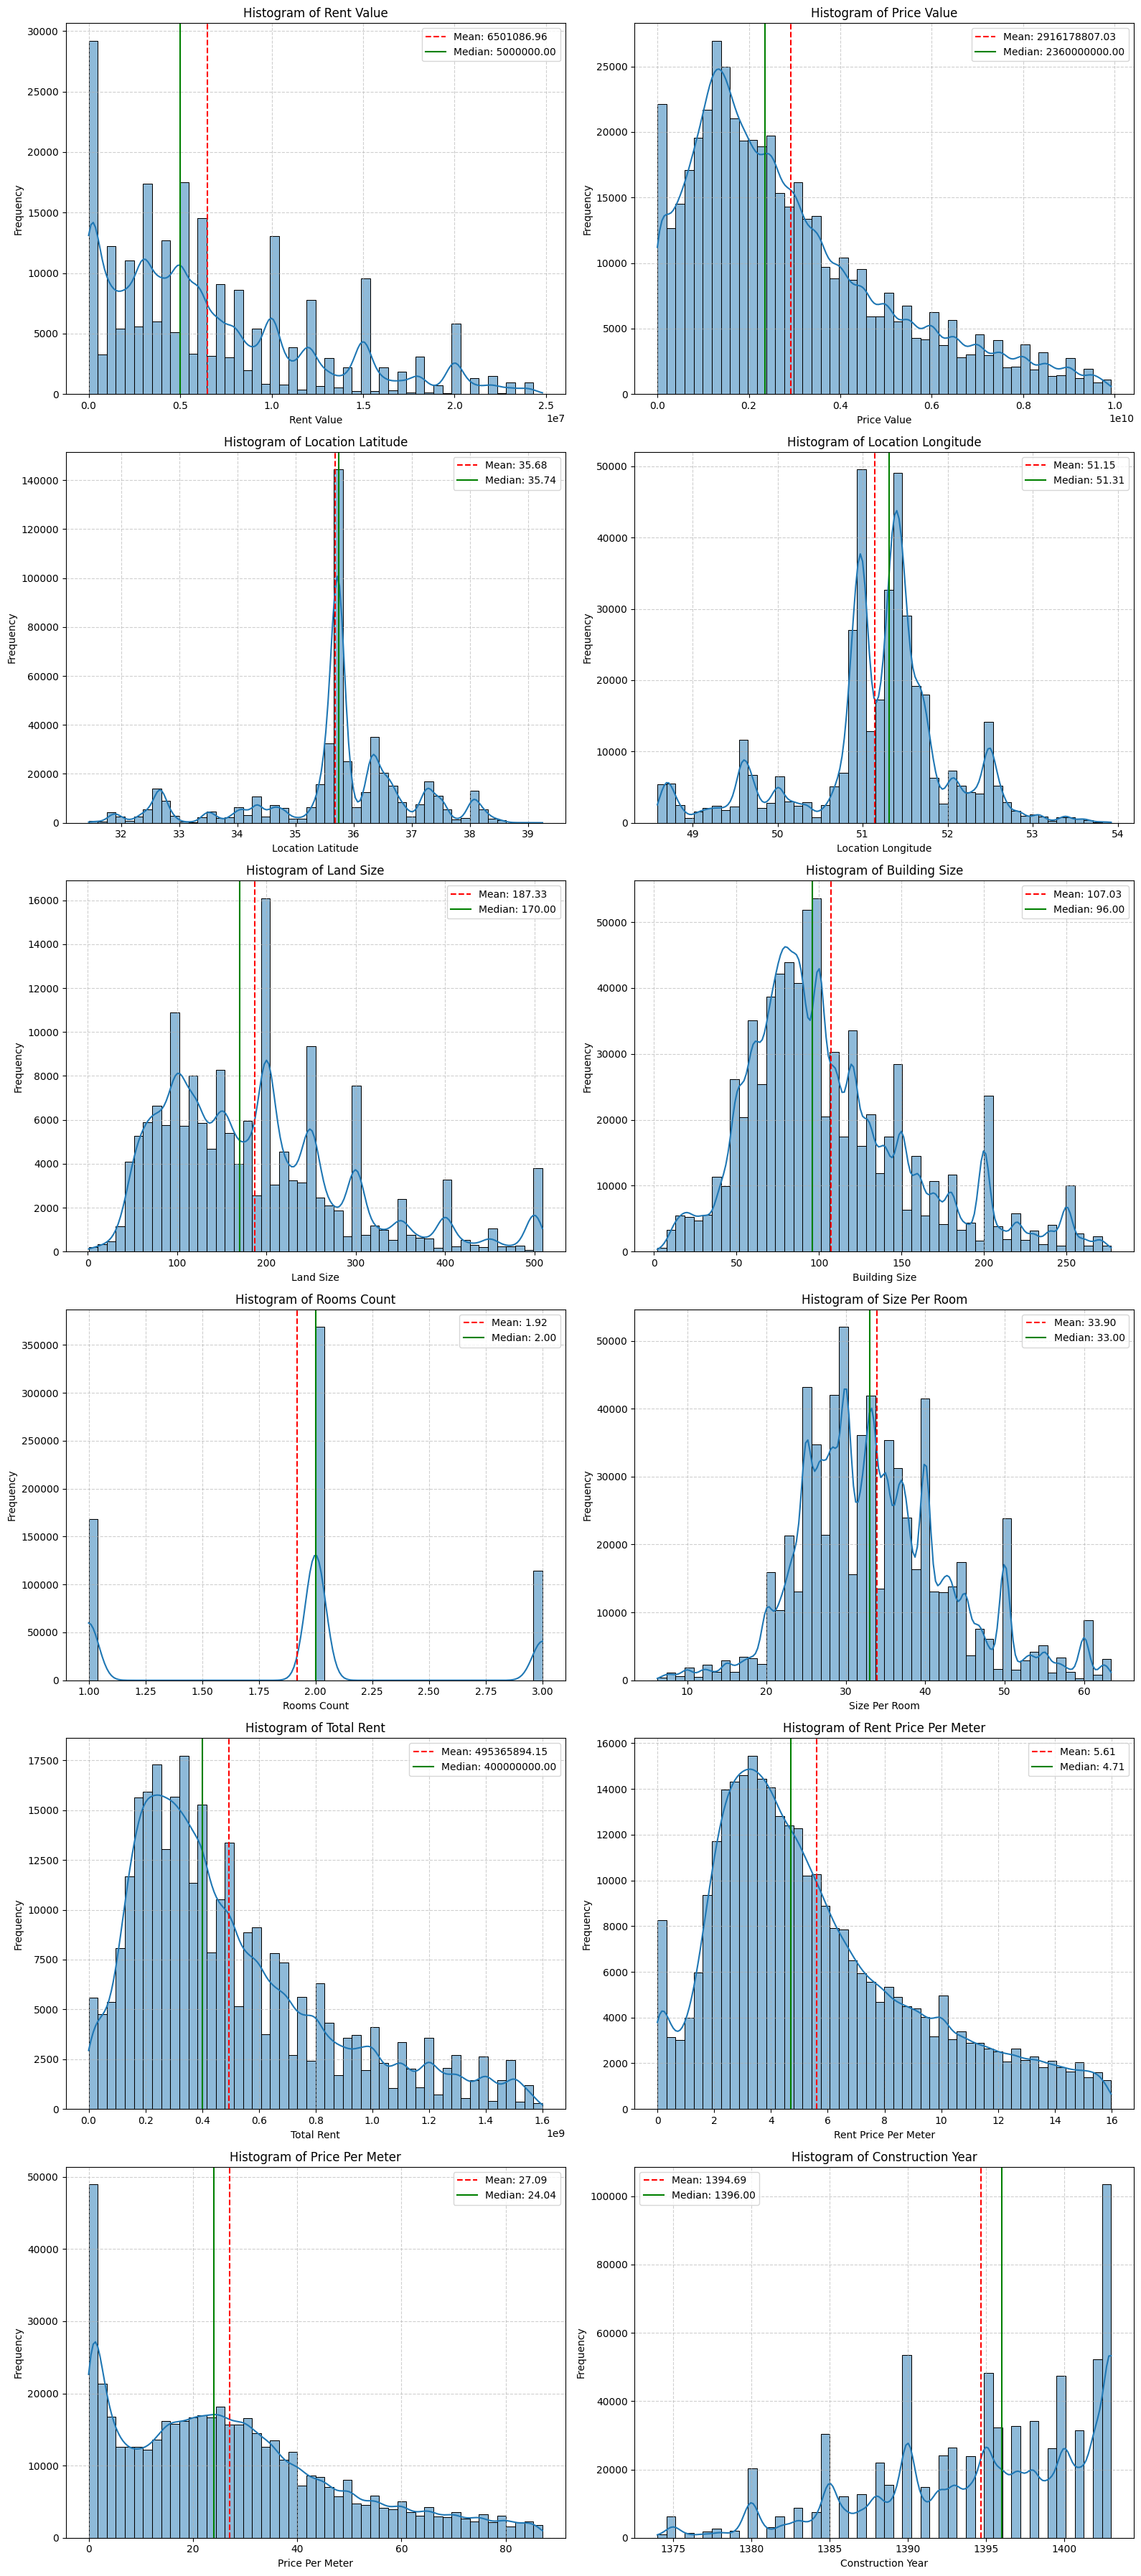

In [11]:
numerical_features_to_plot = ['rent_value','price_value','location_latitude','location_longitude','land_size','building_size','rooms_count',
                             'size_per_room','total_rent','rent_price_per_meter','price_per_meter','construction_year']
num_features = len(numerical_features_to_plot)
num_cols = 2
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6))
axes = axes.flatten()

for i, feature in enumerate(numerical_features_to_plot):
    ax = axes[i]
    
    temp_data = df[feature]
    temp_data = pd.to_numeric(temp_data, errors='coerce')

    
    Q1 = temp_data.quantile(0.25)
    Q3 = temp_data.quantile(0.75)
    IQR = Q3 - Q1

    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers and non-zero values
    temp_series = temp_data[(temp_data > lower_bound) & (temp_data < upper_bound)].dropna()
    temp_series = temp_series[temp_series != 0]

    if temp_series.empty:
        print(f"No data remaining for '{feature}' after outlier removal or after removing zero values. Skipping plot.")
        # Clear the subplot if no data to plot
        fig.delaxes(axes[i])
        continue

    mean_val = temp_series.mean()
    median_val = temp_series.median()

    sns.histplot(temp_series, kde=True, bins=50, ax=ax)

    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

    ax.set_title(f'Histogram of {feature.replace("_", " ").title()}')
    ax.set_xlabel(feature.replace("_", " ").title())
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# Remove any unused subplots if the number of features is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.savefig("1.png") 
plt.tight_layout()
plt.show()


📌categorical features consider for showing histogram are ['cat2_slug', 'cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month', 'user_type', 'rent_mode', 'rent_type', 'price_mode', 'credit_mode', 'rent_credit_transform', 'transformable_price', 'deed_type', 'floor', 'total_floors_count', 'unit_per_floor', 'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking', 'is_rebuilt', 'has_warm_water_provider', 'has_heating_system', 'has_cooling_system', 'has_restroom', 'building_direction', 'floor_material', 'mode_rent_or_price'] 



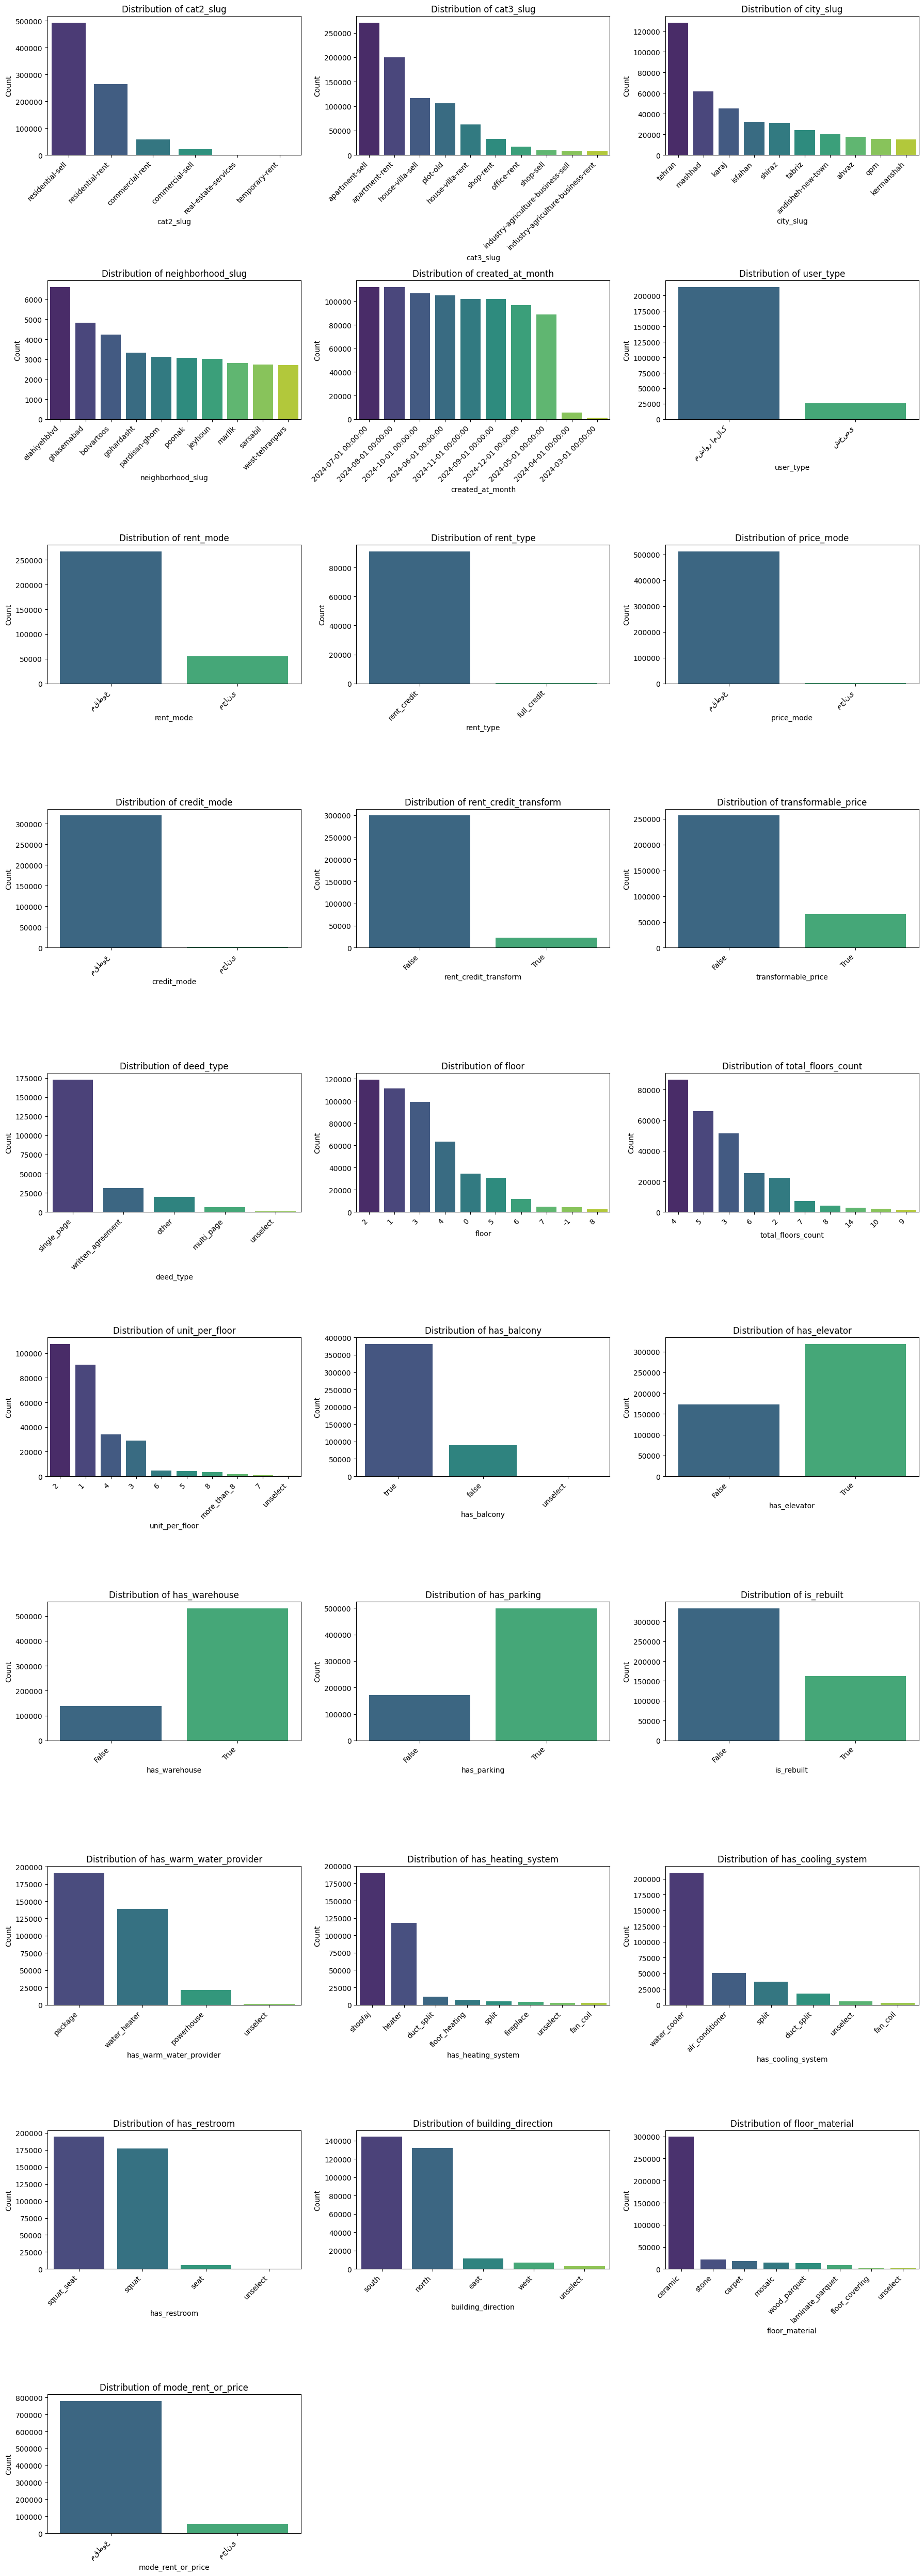

In [12]:
categorical_features = categorical

print('\n📌categorical features consider for showing histogram are',categorical,'\n' )
num_features = len(categorical_features)
num_cols = 3
num_rows = math.ceil(num_features / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 6, num_rows * 5))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(categorical_features):
    ax = axes[i]

    value_counts = df[col].value_counts().head(10)
    sns.barplot(x=value_counts.index, y=value_counts.values, palette='viridis', ax=ax)
    ax.set_title(f'Distribution of {col}', fontsize=12) # Reduced font size for subplots
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45) # Removed ha='right'
    ax.tick_params(axis='y', labelsize=10) # Adjust y-axis label size
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, ha='right') # Added ha='right' here

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.savefig("2.png") 
plt.tight_layout()
plt.show()

<p style="font-family:Nazanin; font-size:150%; text-align:right;" dir="rtl">
    2. ارتباط دو به دوی تعدادی از متغیرها را که تصور می‌کنید به فهم داده کمک می‌کنند، بررسی کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 نمودار زیر توضیح دهنده نحوه توزیع قیمت یک مترمربع از فروش آپارتمان های مسکونی در نقاط مختلف کشور
</p>

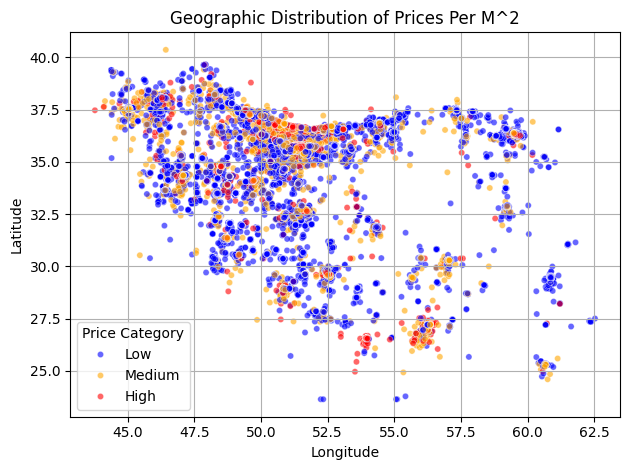

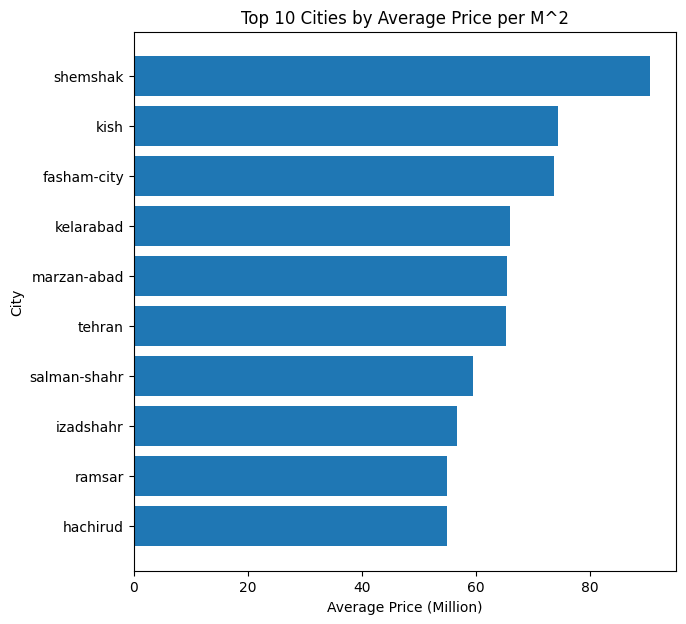

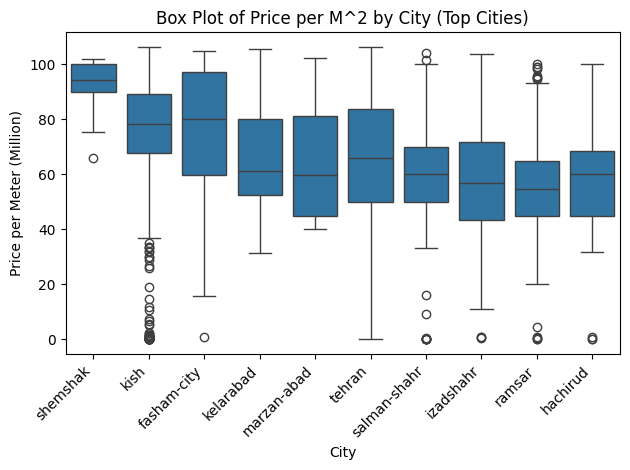

In [13]:
df_temp = df.copy(['location_latitude','location_longitude','cat2_slug','cat3_slug','price_per_meter'])
#exclude zero coordinated inserted during cleaning for handing nan.
df_temp = df_temp[(df_temp['location_latitude'] != 0.0) & (df_temp['location_longitude'] != 0.0)].copy()
df_temp = df_temp[(df['cat2_slug']=='residential-sell') & (df_temp['cat3_slug']=='apartment-sell')] 
# calculate bins and labels for price_category 
bins= [
    df_temp['price_per_meter'].min() - 1,
    df_temp['price_per_meter'].quantile(0.33),
    df_temp['price_per_meter'].quantile(0.66),
    df_temp['price_per_meter'].max() + 1
]
labels = ['Low', 'Medium', 'High']

df_temp['price_category'] = pd.cut(df_temp['price_per_meter'], bins=bins, labels=labels)

sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=df_temp,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.6,
    s=20
)
plt.title('Geographic Distribution of Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.grid(True)
plt.tight_layout()
plt.show()


avg_price_per_city = df_temp.groupby('city_slug')['price_per_meter'].mean().reset_index()
avg_price_per_city = avg_price_per_city.sort_values('price_per_meter', ascending=False)

avg_price_per_city = avg_price_per_city[avg_price_per_city['price_per_meter'].notnull()]

# Select top 10 cities for the bar chart
avg_price_per_city_top10 = avg_price_per_city.head(10)


plt.figure(figsize = (7, 7))
plt.barh(
    avg_price_per_city_top10['city_slug'],
    avg_price_per_city_top10['price_per_meter']
)
plt.xlabel('Average Price (Million)')
plt.ylabel('City')
plt.title('Top 10 Cities by Average Price per M^2')
plt.gca().invert_yaxis()
plt.show()

top_cities = avg_price_per_city.head(10)['city_slug'].tolist()
df_temp_top_cities = df_temp[df_temp['city_slug'].isin(top_cities)].copy()

#plt.figure(figsize=(7, 7))
sns.boxplot(x='city_slug', y='price_per_meter', data=df_temp_top_cities, order=top_cities) # Order by average price
plt.title('Box Plot of Price per M^2 by City (Top Cities)')
plt.xlabel('City')
plt.ylabel('Price per Meter (Million)')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("3.png") 
plt.show()

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
خروجی زیر نشان دهنده این است که هر یک از آگهی های فروش یا اجاره مربوط به چه نوع مسکن می شود </p>

In [14]:
df.groupby('cat2_slug')['cat3_slug'].value_counts()

cat2_slug             cat3_slug                         
commercial-rent       shop-rent                              32936
                      office-rent                            17174
                      industry-agriculture-business-rent      8761
commercial-sell       shop-sell                               9836
                      industry-agriculture-business-sell      8932
                      office-sell                             2710
real-estate-services  presell                                    5
                      partnership                                1
residential-rent      apartment-rent                        200395
                      house-villa-rent                       62853
residential-sell      apartment-sell                        270543
                      house-villa-sell                      116019
                      plot-old                              105735
temporary-rent        villa                                      2
     

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 نمودار زیر توضیح دهنده متوسط قیمت فروش یک متر مربع از آگهی های فروش در هر سال است
</p>

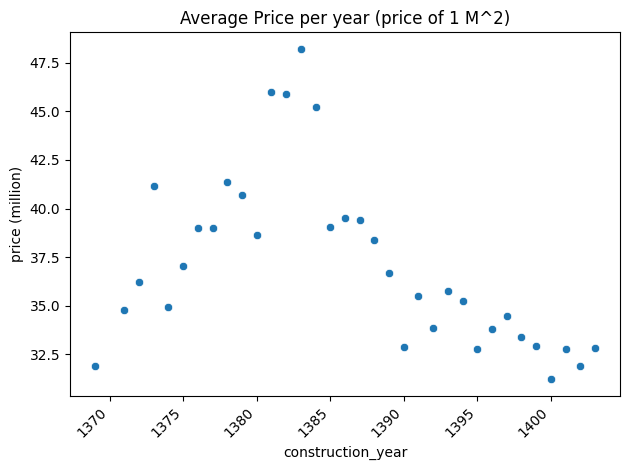

In [15]:
df_avg_year = df[df.construction_year != 0]
avg_price_per_year = df_avg_year.groupby('construction_year')['price_per_meter'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('construction_year', ascending=True)
#plot data
sns.scatterplot(x = 'construction_year', y = 'price_per_meter', data = avg_price_per_year)
plt.title('Average Price per year (price of 1 M^2)')
plt.ylabel('price (million)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("4.png") 
plt.show()

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 نمودار زیر توضیح دهنده متوسط اجاره یک مترمربع در سالهای مختلف است
</p>

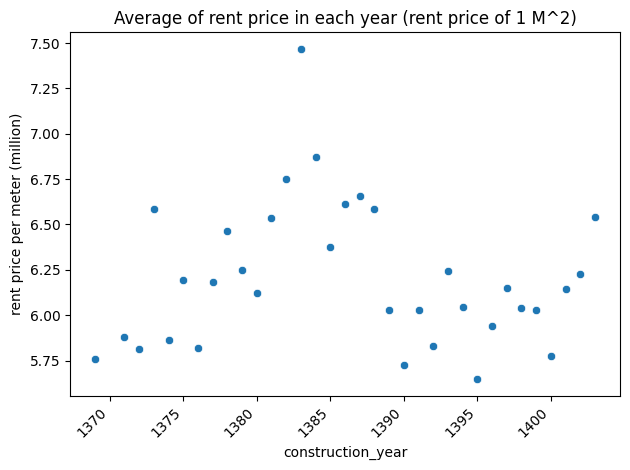

In [16]:
df_avg_year = df[df.construction_year != 0]
avg_price_per_year = df_avg_year.groupby('construction_year')['rent_price_per_meter'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('construction_year', ascending=True)
#plot data
sns.scatterplot(x = 'construction_year', y = 'rent_price_per_meter', data = avg_price_per_year)
plt.title('Average of rent price in each year (rent price of 1 M^2)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('rent price per meter (million)')
plt.tight_layout()
plt.savefig("5.png") 
plt.show()

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
 نمودار زیر توضیح دهنده نحوه توزیع قیمت اجاره یک مترمربع از اجاره آپارتمان های مسکونی در نقاط مختلف کشور
</p>

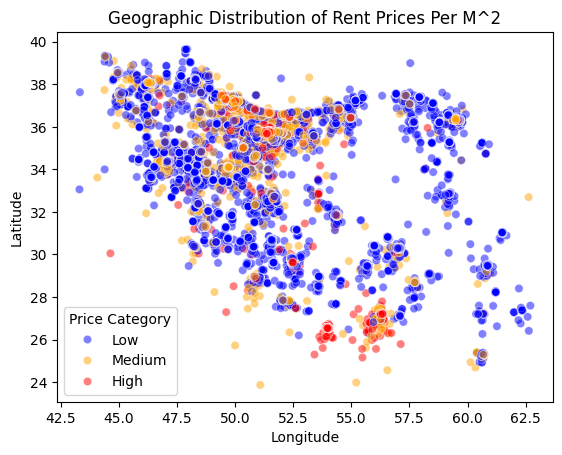

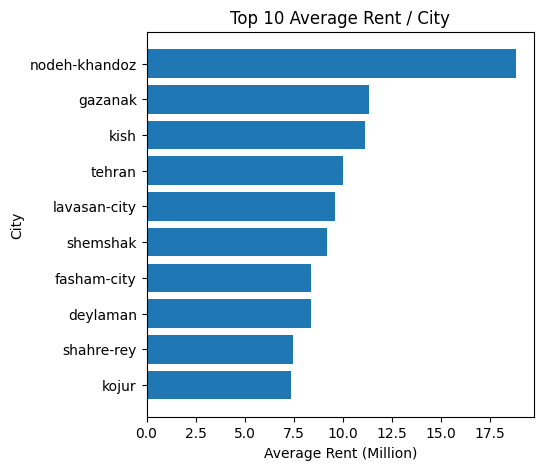

In [17]:
df_temp = df.copy()
#exclude zero coordinated inserted during cleaning for handing nan.
df_temp = df_temp[(df_temp['location_latitude'] != 0.0) & (df_temp['location_longitude'] != 0.0)].copy()


# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = df_temp['total_rent'].quantile(0.25)
Q3 = df_temp['total_rent'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

df_rent = df_temp[(df_temp['cat2_slug']=='residential-rent') &
              (df_temp['cat3_slug']=='apartment-rent') &
              (df_temp['total_rent'] > lower_bound) &
              (df_temp['total_rent'] < upper_bound)]

#df_rent['price_category'] = pd.cut(df_rent['rent_price_per_meter'], bins=bins, labels=labels)
df_rent = df_rent[df_rent['rent_price_per_meter'].notna()].copy()
df_rent['price_category'] = pd.qcut(
    df_rent['rent_price_per_meter'], 3, labels=['Low','Medium','High']
)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=df_rent,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Rent Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()

avg_rent_per_city = df_rent.groupby('city_slug')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_city = avg_rent_per_city.sort_values('rent_price_per_meter', ascending=False)
avg_rent_per_city[avg_rent_per_city['rent_price_per_meter'].notnull()]
avg_rent_per_city = avg_rent_per_city.head(10)
plt.figure(figsize = (5, 5))

plt.barh(
    avg_rent_per_city['city_slug'],
    avg_rent_per_city['rent_price_per_meter']
)
plt.xlabel('Average Rent (Million)')
plt.ylabel('City')
plt.title('Top 10 Average Rent / City')
plt.gca().invert_yaxis()
plt.savefig("6.png") 
plt.show()



<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. نکات قابل توجهی را که از بررسی توزیع‌ها و نمودارهای پراکندگی و مقدار همبستگی دریافتید فهرست کنید.
</p>

In [18]:
df_cor = df.copy()
# Convert booleans-like strings to numeric 1/0
bool_cols = [c for c in df_cor.columns if df_cor[c].dtype == 'object' and
             set(df_cor[c].dropna().unique()).issubset({'TRUE', 'FALSE', 'True', 'False','true','false'})]

for col in bool_cols:
    df_cor[col] = df_cor[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

# Convert categorical columns to category codes
for col in categorical:
    if df_cor[col].dtype == 'object':
        df_cor[col] = df_cor[col].astype('category').cat.codes

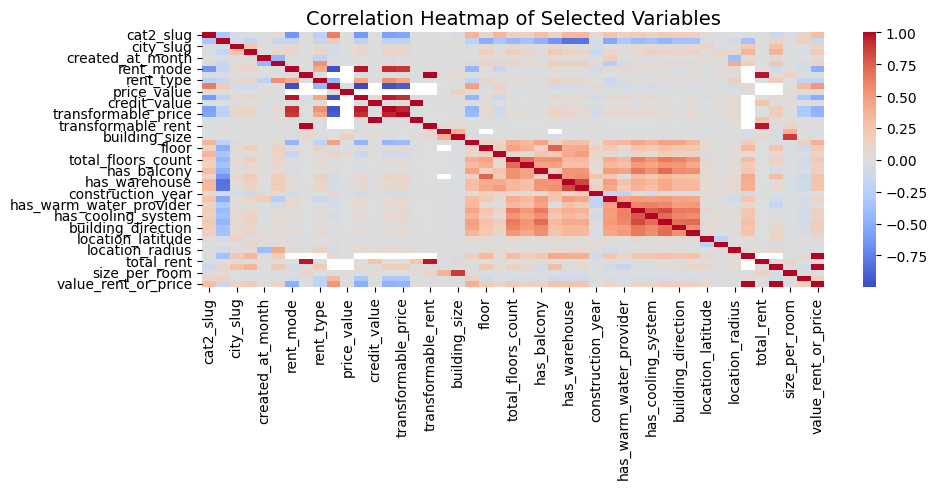

Pairs of columns with absolute correlation > 0.8:
there is strong negative correlation between price_mode - rent_mode: -0.966 

there is strong positive correlation between credit_mode - rent_mode: 0.965 

there is strong negative correlation between credit_mode - price_mode: -0.997 

there is strong positive correlation between rent_credit_transform - rent_mode: 0.921 

there is strong negative correlation between rent_credit_transform - price_mode: -0.955 

there is strong positive correlation between rent_credit_transform - credit_mode: 0.955 

there is strong positive correlation between transformable_price - rent_mode: 0.884 

there is strong negative correlation between transformable_price - price_mode: -0.918 

there is strong positive correlation between transformable_price - credit_mode: 0.919 

there is strong positive correlation between transformable_price - rent_credit_transform: 0.942 

there is strong positive correlation between transformable_credit - credit_value: 1.00

In [19]:
#--------------------check the correlation between numerical and categorical columns -------------------#
corr_matrix = df_cor.corr(numeric_only=True)

# Visualize correlations (heatmap)
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Selected Variables', fontsize=14)
plt.tight_layout()
plt.savefig("7.png") 
plt.show()

#findout the correlation between values in corr_matrix
high_corr_pairs = []
# Iterate through the correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i): # Start from j=0 to avoid duplicate pairs and the diagonal
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            correlation_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, correlation_value))

# Print the pairs
print("Pairs of columns with absolute correlation > 0.8:")
for pair in high_corr_pairs:
    if pair[2] > 0 :
      print(f"there is strong positive correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")
    else:
      print(f"there is strong negative correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")


<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. آیا چیزی از جنس تناقض و ناسازگاری مقداری در داده مشاهده می‌کنید؟ به عنوان نمونه به این صورت که در یک سلول مقدار غیرمرتبط و از نظر منطقی نادرست نوشته شده باشد. مثلا در ستونی که قرار است متن بیاید عدد آمده باشد یا در ستونی که قرار است عدد یک یا دو رقمی بیاید، مقدار متفاوتی ثبت شده است.
</p>

<p style="font-family:Nazanin; font-size:200%; text-align:right;color:blue;" dir="rtl">
    بخش چهارم : تحلیل آگهی های املاک و بازار املاک ایران
    
</p>

<div style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">    <h5 >
 ارزانترین شهرها برای اجاره مسکن
</h5>
</div>

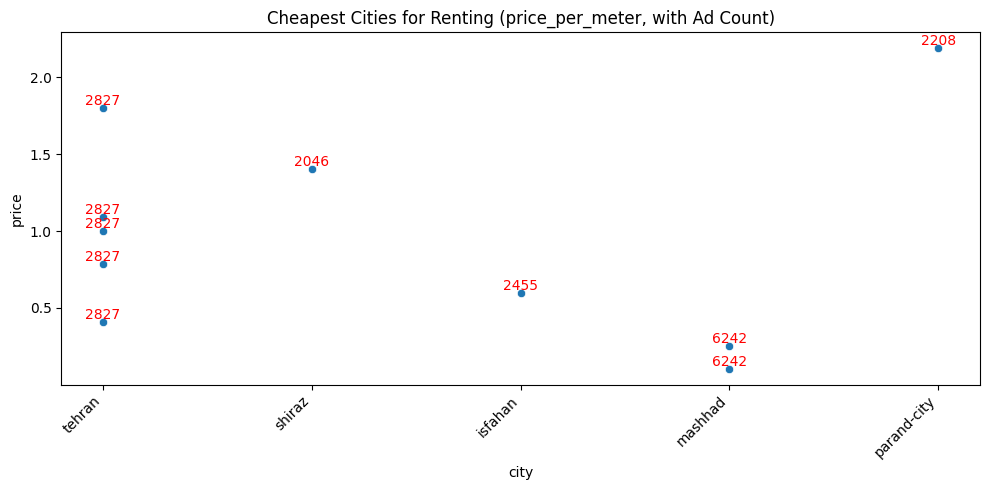

In [20]:
df_rent = df.copy()


df_rent= df_rent[df_rent['rent_price_per_meter'] > 0].copy()

Q1 = df_rent['rent_price_per_meter'].quantile(0.25)
Q3 = df_rent['rent_price_per_meter'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep non-outliers only based on the filtered data
df_rent_no_outliers = df_rent[
    (df_rent['rent_price_per_meter'] >= lower_bound) &
    (df_rent['rent_price_per_meter'] <= upper_bound)
].copy()


city_cheap_rent = df_rent_no_outliers[df_rent_no_outliers['rent_price_per_meter'] < Q1][
    ['city_slug', 'rent_price_per_meter']
].copy()


# count ads per city
city_counts = city_cheap_rent['city_slug'].value_counts().reset_index(name='count')

# merge counts back
city_cheap_rent = city_cheap_rent.merge(city_counts, on='city_slug')

top10 = city_cheap_rent.head(10)

plt.figure(figsize=(10,5))

sns.scatterplot(
        x='city_slug',
        y='rent_price_per_meter',
        data=top10
    )

plt.title('Cheapest Cities for Renting (price_per_meter, with Ad Count)')
plt.ylabel('price')
plt.xlabel('city')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

    # annotate points with ad count
for i, row in top10.iterrows():
        plt.text(
            row['city_slug'],
            row['rent_price_per_meter'],
            str(row['count']),
            ha='center', va='bottom', color='red'
        )
plt.savefig("8.png") 
plt.show()

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
 <h5><b>ذینفع: سرمایه گذار</b></h5>
    <h5>
    شناسایی محله‌های سودآور سرمایه‌گذاری: باید دو شاخص کلیدی را به‌صورت همزمان تحلیل کنیم،
    بنابراین هدف پیدا کردن محله هایی است که:
  </h5>
  <ul>
    <li>رشد قیمت پایدار یا مثبت در طول زمان دارند (قیمت رو به افزایش و نه نوسانی یا نزولی)،</li>
    <li>عرضهٔ کم (تعداد آگهی کم نسبت به سایر محله‌ها) ⇒ یعنی تقاضا بالاتر از عرضه است، پس ملک دیرتر خالی می‌ماند و ارزش سرمایه‌ای بیشتر می‌شود.</li>
  </ul>
</div>

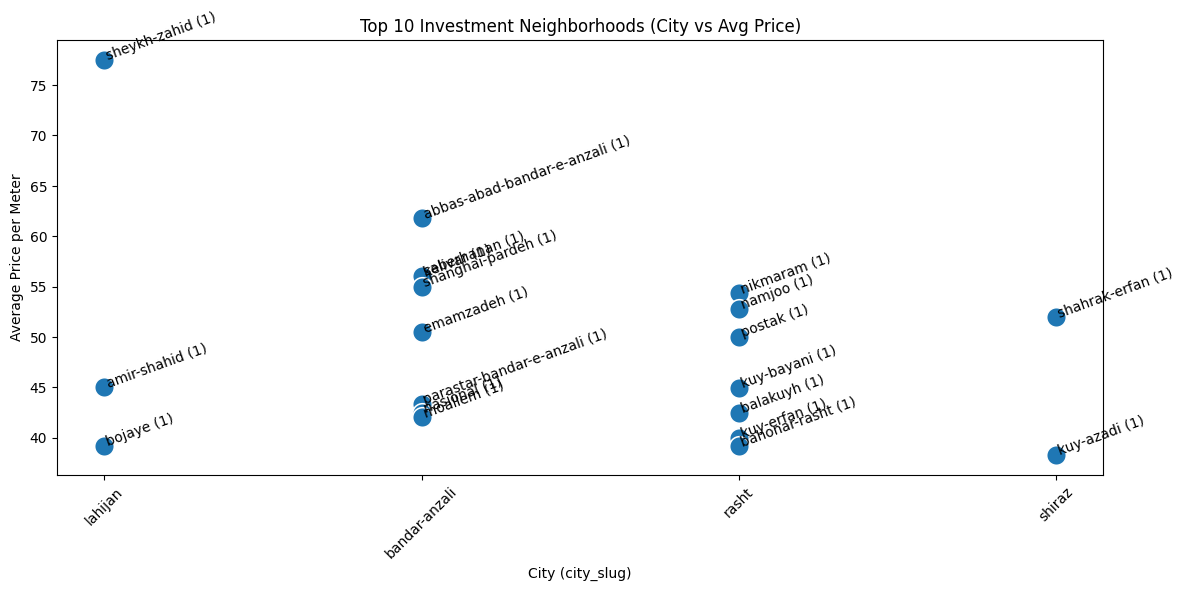

In [21]:
price_data = df.copy()
columns_need= ['city_slug', 'neighborhood_slug', 'price_per_meter']
investment_data = price_data[columns_need].copy()

investment_data = investment_data[investment_data['price_per_meter'] > 0].copy()

investment_data = investment_data.dropna(subset=['city_slug', 'neighborhood_slug', 'price_per_meter'])

# Group by city and neighborhood to get average price and number of ads
grouped_investment_data = investment_data.groupby(['city_slug', 'neighborhood_slug']).agg(
    avg_price_per_meter = ('price_per_meter', 'mean'),
    median_price_per_meter = ('price_per_meter', 'median'),
    ad_count = ('price_per_meter', 'count')
).reset_index()

#Sort results by average price
grouped_investment_data_sorted = grouped_investment_data.sort_values(by='avg_price_per_meter', ascending=False)


grouped_investment_data['investment_score'] = (
    (grouped_investment_data['avg_price_per_meter'] / grouped_investment_data['avg_price_per_meter'].max()) *
    (1 / (grouped_investment_data['ad_count']))
)


top_10_investments = grouped_investment_data.sort_values(by='investment_score', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.scatterplot(x='city_slug', y='avg_price_per_meter', data=top_10_investments, s=200)

for i in range(len(top_10_investments)):
    plt.text(
        (top_10_investments['city_slug'].iloc[i]),
        top_10_investments['avg_price_per_meter'].iloc[i],
        f"{top_10_investments['neighborhood_slug'].iloc[i]} ({top_10_investments['ad_count'].iloc[i]})",
        fontsize=10,
        rotation=20
    )

plt.xlabel("City (city_slug)")
plt.ylabel("Average Price per Meter")
plt.title("Top 10 Investment Neighborhoods (City vs Avg Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("9.png") 
plt.show()

In [23]:
df_year_price = df.copy(['construction_year','price_per_meter'])

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h5>
چه حجمی از مسکن های ساخته شده در سال های اخیر قیمت بالایی دارند؟ 
</h5>

<h5><b>به کمک این روش می‌توانید:</b></h5>

<ul>
  <li>✅ تشخیص دهید که آیا بر روی خانه های گران قیمت سرمایه گذاری کنید یا ارزان قیمت .</li>

</ul>

</div>

In [24]:
df_year_price = df[['construction_year','price_per_meter']].copy()

# Convert the column to numeric, coercing errors to NaN
df['construction_year'] = pd.to_numeric(df['construction_year'], errors='coerce')

# Remove rows where construction_year is NaN
original_rows = df.shape[0]
df.dropna(subset=['construction_year'], inplace=True)
removed_rows = original_rows - df.shape[0]

max_year = df['construction_year'].max()
recent_years = [year for year in range(int(max_year) - 4, int(max_year) + 1)]

print(f"Considering recent construction years from {min(recent_years)} to {max_year}.")

Q3_price_per_meter = df['price_per_meter'].quantile(0.75)

print(f"The 75th percentile (Q3) for 'price_per_meter' is: {Q3_price_per_meter}")

recent_construction_data = df[df['construction_year'].isin(recent_years)]

high_priced_new_houses = recent_construction_data[recent_construction_data['price_per_meter'] > Q3_price_per_meter]

percentage_high_priced_new_houses = (len(high_priced_new_houses) / len(recent_construction_data)) * 100 if len(recent_construction_data) > 0 else 0

print(f"Number of houses built in recent years ({min(recent_years)}-{max(recent_years)}): {len(recent_construction_data)}")
print(f"Number of high-priced houses among these: {len(high_priced_new_houses)}")
print(f"Percentage of high-priced new houses: {percentage_high_priced_new_houses:.2f}%")

Considering recent construction years from 1399 to 1403.
The 75th percentile (Q3) for 'price_per_meter' is: 45.925925925925924
Number of houses built in recent years (1399-1403): 260858
Number of high-priced houses among these: 37922
Percentage of high-priced new houses: 14.54%


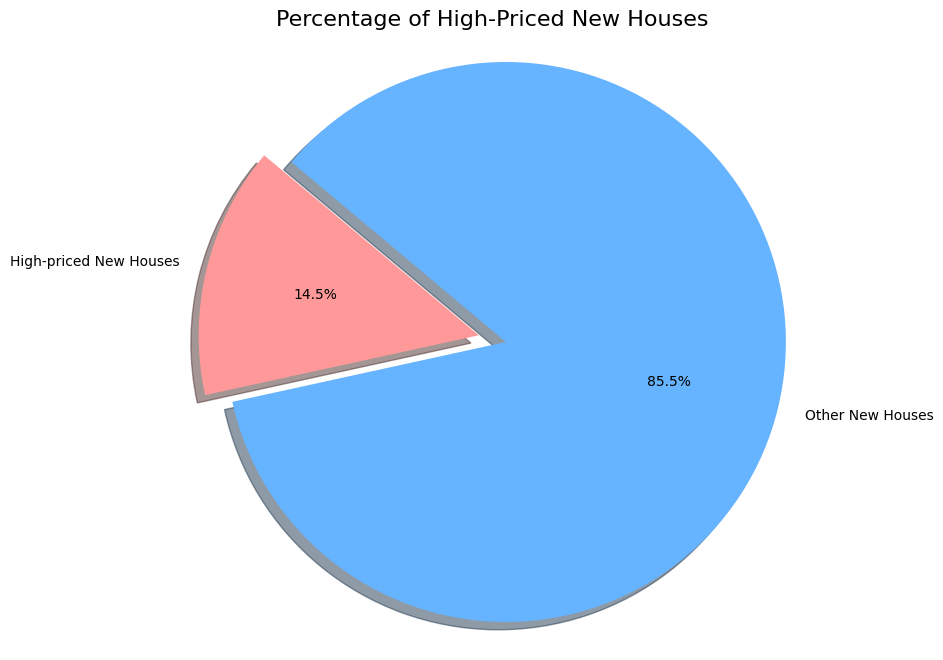

In [25]:
labels = ['High-priced New Houses', 'Other New Houses']
sizes = [percentage_high_priced_new_houses, 100 - percentage_high_priced_new_houses]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # Explode the 1st slice (High-priced New Houses)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of High-Priced New Houses', fontsize=16)
plt.savefig("10.png") 
plt.show()

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">

<h5><b>ذینفع: طراحان داخلی</b></h5>

<h5>
با استفاده از این روش تحلیلی، می‌توانیم شهرها و مناطقی را شناسایی کنیم که بالاترین پتانسیل برای ارائه خدمات طراحی داخلی را دارند. این تحلیل بر اساس داده‌های واقعی املاک انجام می‌شود و به شما کمک می‌کند تصمیم‌گیری دقیق‌تر و هدفمندتری داشته باشید.
</h5>

<h5><b>به کمک این روش می‌توانید:</b></h5>

<ul>
  <li>✅ تشخیص دهید کدام شهرها بیشترین ظرفیت و تقاضا برای پروژه‌های طراحی داخلی را دارند.</li>
  <li>✅ بفهمید در کدام مناطق تعداد بازسازی و نوسازی بیشتر است (مشتریان آماده همکاری).</li>
  <li>✅ شناسایی کنید کدام مناطق بیشترین فایل پیش‌فروش را دارند (ساختمان‌های تازه‌ساز).</li>
  <li>✅ بررسی کنید در کدام مناطق میانگین متراژ واحدها بالاتر است (پروژه‌های بزرگ‌تر و سودآورتر).</li>
</ul>

</div>


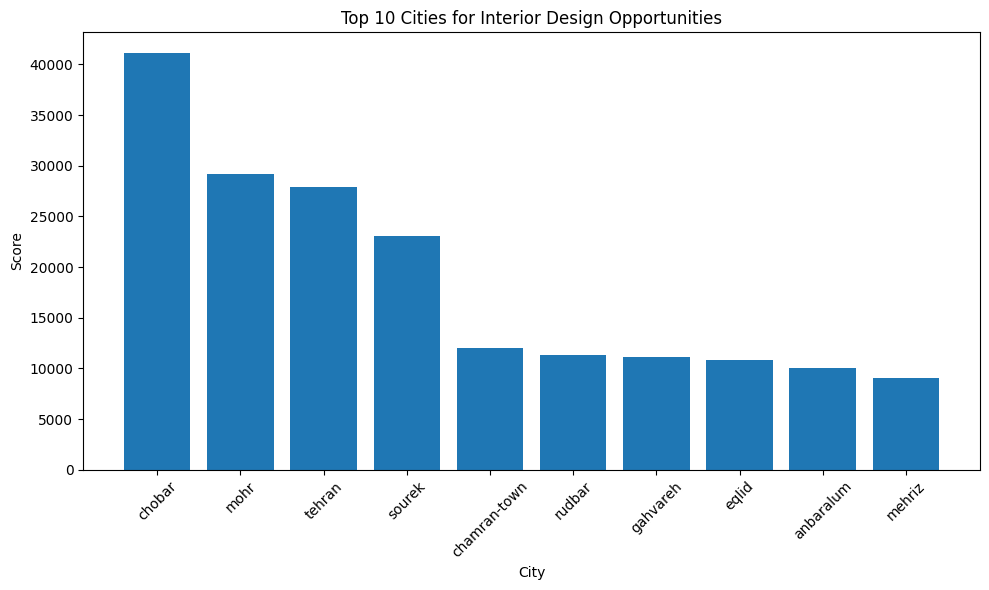

In [26]:
df_tarah = df[['cat3_slug','city_slug', 'neighborhood_slug', 'price_per_meter','building_size','is_rebuilt']].copy()

#use clean dataframe
rebuilt_houses = df_tarah[df_tarah['is_rebuilt'] == True]
# use original dataframe
pre_sell = data[data['cat3_slug'] == 'presell']

rebuilt_by_city = rebuilt_houses.groupby('city_slug').size().reset_index(name='rebuilt_count')
pre_sell_by_city = pre_sell.groupby('city_slug').size().reset_index(name='pre_sell_count')
large_houses = df.groupby('city_slug')['building_size'].mean().reset_index(name='avg_building_size')

#merge all these
city_summary = rebuilt_by_city.merge(pre_sell_by_city, on='city_slug', how='outer') \
                              .merge(large_houses, on='city_slug', how='outer')

#calculat a score based on the importannce of each feature! rebuilt is most important.
city_summary = city_summary.fillna(0)
city_summary['score'] = (
    city_summary['rebuilt_count'] * 0.6 +
    city_summary['pre_sell_count'] * 0.3 +
    city_summary['avg_building_size'] * 0.1
)

best_cities = city_summary.sort_values('score', ascending=False).head(10)

#plot
plt.figure(figsize=(10, 6))
plt.bar(best_cities['city_slug'], best_cities['score'])
plt.title('Top 10 Cities for Interior Design Opportunities')
plt.xlabel('City')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("11.png") 
plt.show()


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h5><b>ذینفع: مشاورین املاک</b></h5>
<h5>با استفاده از این تحلیل:</h5>
<ul>
  <li>✔ مشخص می‌کنید <strong>کدام شهرها و محله‌ها بیشترین سود را برای راه‌اندازی دفتر دارند</strong>.</li>
  <li>✔ مناطقی که ترکیبی از قیمت بالا، واحدهای بزرگ و معاملات متعدد دارند، به عنوان <strong>مناطق بهینه برای تمرکز فعالیت</strong> شناسایی می‌شوند.</li>
  <li>✔ تصمیم‌گیری شما برای جذب مشتری و انتخاب محل دفتر با داده‌های واقعی و عددی پشتیبانی می‌شود.</li>
</ul>
<h5>بنابراین، تحلیل Profit Score به شما امکان می‌دهد <strong>استراتژی هوشمندانه‌ای برای افزایش سود و بهره‌وری کسب‌وکار مشاور املاک</strong> طراحی کنید.</h5>
<h5>بنابراین، تحلیل Profit Score به شما امکان می‌دهد <strong>استراتژی هوشمندانه‌ای برای افزایش سود و بهره‌وری کسب‌وکار مشاور املاک</strong> طراحی کنید.</h5>
</div>


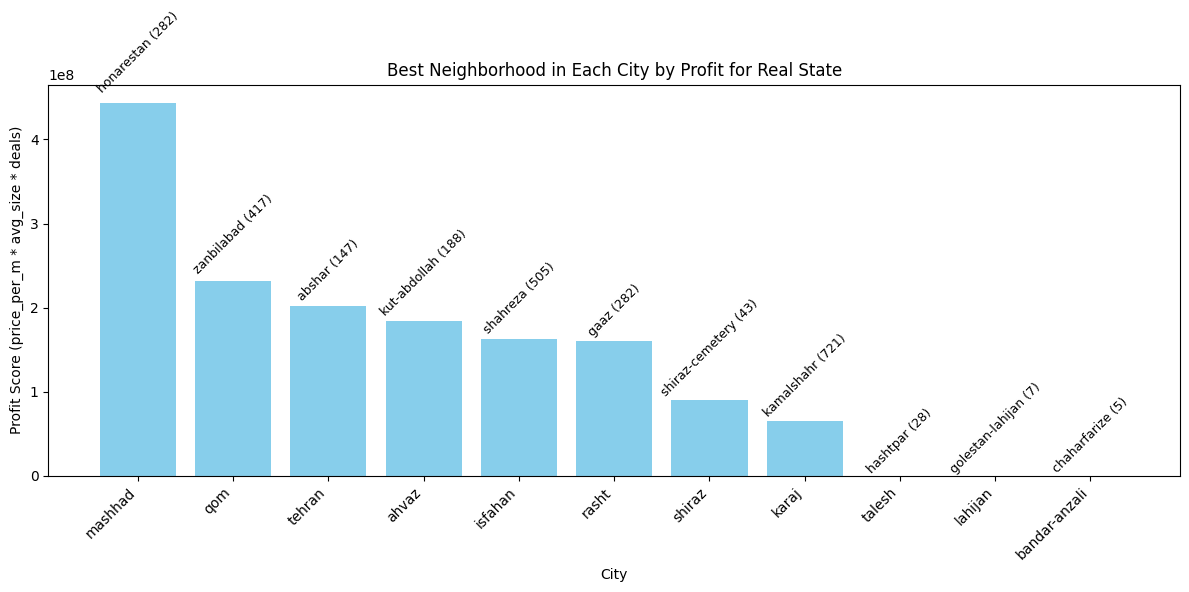

In [27]:
df_moshaver_amlak = df[['city_slug', 'neighborhood_slug', 'price_per_meter','building_size','price_value']].copy()

# Group by city_slug and neighborhood_slug
grouped = df_moshaver_amlak.groupby(['city_slug','neighborhood_slug']).agg(
    avg_price_value=('price_value', 'mean'),
    avg_price_per_m=('price_per_meter', 'mean'),
    avg_size=('building_size', 'mean'),
    deal_count=('price_value', 'count')
).reset_index()

# formula is profit_score = price_per_m * size_of_house * number of contract
grouped['profit_score'] = grouped['avg_price_per_m'] * grouped['avg_size'] * grouped['deal_count']

best_neighborhoods = grouped.loc[grouped.groupby('city_slug')['profit_score'].idxmax()]
best_neighborhoods = best_neighborhoods.sort_values('profit_score', ascending=False)

#print(best_neighborhoods)

plt.figure(figsize=(12,6))
bars = plt.bar(best_neighborhoods['city_slug'], best_neighborhoods['profit_score'], color='skyblue')

# Step 3: Add neighborhood name and number of deals on top of each bar
for bar, heigh, deals in zip(bars, best_neighborhoods['neighborhood_slug'], best_neighborhoods['deal_count']):
    height = bar.get_height()
    # Write neighborhood name
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + height*0.02,
        f"{heigh} ({deals})",
        ha='center', va='bottom', fontsize=9, rotation=45,
        color='black'
    )

plt.xticks(rotation=45, ha='right')
plt.title('Best Neighborhood in Each City by Profit for Real State')
plt.xlabel('City')
plt.ylabel('Profit Score (price_per_m * avg_size * deals)')
plt.tight_layout()
plt.savefig("12.png") 
plt.show()


In [28]:
df_temp = df[['city_slug', 'neighborhood_slug', 'rent_value','credit_value','construction_year', 'rent_price_per_meter', 'cat2_slug','cat3_slug']]
df_temp = df[df['cat2_slug']=='residential-rent']

In [29]:
# Avg for each neighbor

df_neighbor_avg_rent = df_temp.groupby(['city_slug','neighborhood_slug']).agg(
    avg_rent_value = ('rent_value', 'mean'),
    avg_rent_per_meter = ('rent_price_per_meter', 'mean')
).reset_index()

df_neighbor_avg_rent

,city_slug,neighborhood_slug,avg_rent_value,avg_rent_per_meter
0,ahvaz,amaniyeh-ahvaz,6.710606e+06,4.159908
1,ahvaz,ariyashahr,2.933333e+06,4.237489
2,ahvaz,baharestan-ahvaz,1.796874e+06,3.393013
3,ahvaz,bahonar,2.102599e+06,4.453109
4,ahvaz,camplojonoobi,1.496569e+06,3.404794
...,...,...,...,...
1097,tehran,zamzam,3.951036e+06,6.659146
1098,tehran,zargandeh,1.766194e+07,13.606144
1099,tehran,zarkesh,6.035000e+06,9.600053
1100,tehran,zehtabi,2.561538e+06,7.088437


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h5>
محله هایی را پیدا کنیم که میانگین اجاره در آنها از میانگین متوسط شهرشان کمتر باشه
</h5>
</div>

In [30]:
#Avg for each City

df_avg_each_city = df_temp.groupby('city_slug')['rent_price_per_meter'].mean().reset_index()

df_avg_each_city.rename(columns={'rent_price_per_meter': 'avg_rent_city'}, inplace=True)

df_avg_each_city


,city_slug,avg_rent_city
0,Iranshahr,1.865820
1,Kordkuy,2.557441
2,aalasht,0.775000
3,abadan,2.857721
4,abadeh,2.526974
...,...,...
402,zargarshahr,4.857143
403,zarghan,2.392437
404,zibakenar,4.474691
405,ziraab,3.116194


In [31]:
df_merge = df_neighbor_avg_rent.merge(df_avg_each_city, on = 'city_slug')

df_merge
neighbor_under_avg = df_merge[df_merge['avg_rent_per_meter'] < df_merge['avg_rent_city']]

neighbor_under_avg['city_slug'].value_counts()


city_slug
tehran           221
isfahan          133
shiraz           126
mashhad           96
karaj             56
ahvaz             42
rasht             36
qom               18
lahijan            2
bandar-anzali      1
Name: count, dtype: int64

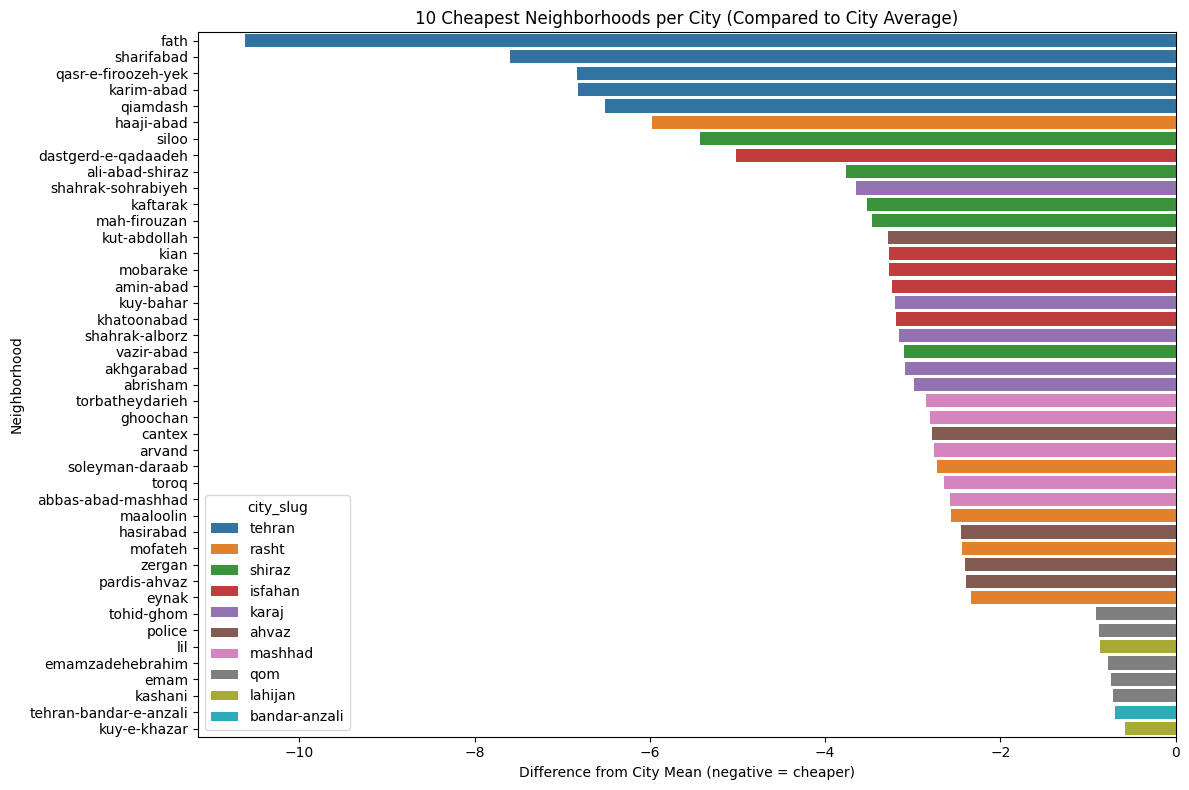

In [32]:
neighbor_under_avg['diff_from_avg_city'] = neighbor_under_avg['avg_rent_per_meter'] - neighbor_under_avg['avg_rent_city']

top10_per_city = (
    neighbor_under_avg
    .sort_values(['city_slug', 'diff_from_avg_city'])
    .groupby('city_slug')
    .head(5)
)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top10_per_city.sort_values('diff_from_avg_city'),
    y='neighborhood_slug',
    x='diff_from_avg_city',
    hue='city_slug',
    dodge=False
)

plt.title('10 Cheapest Neighborhoods per City (Compared to City Average)')
plt.xlabel('Difference from City Mean (negative = cheaper)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.savefig("13.png") 
plt.show()




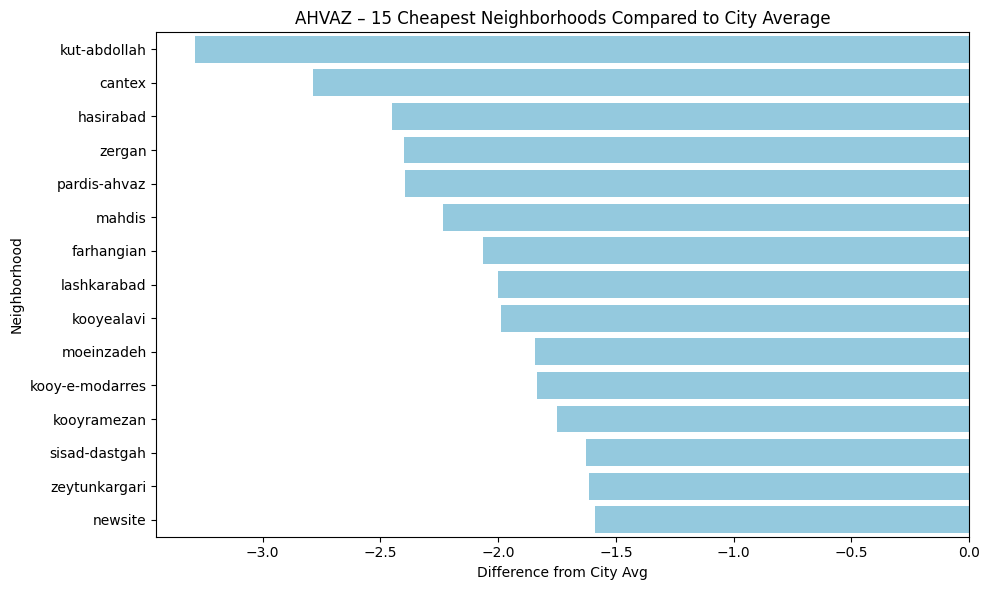

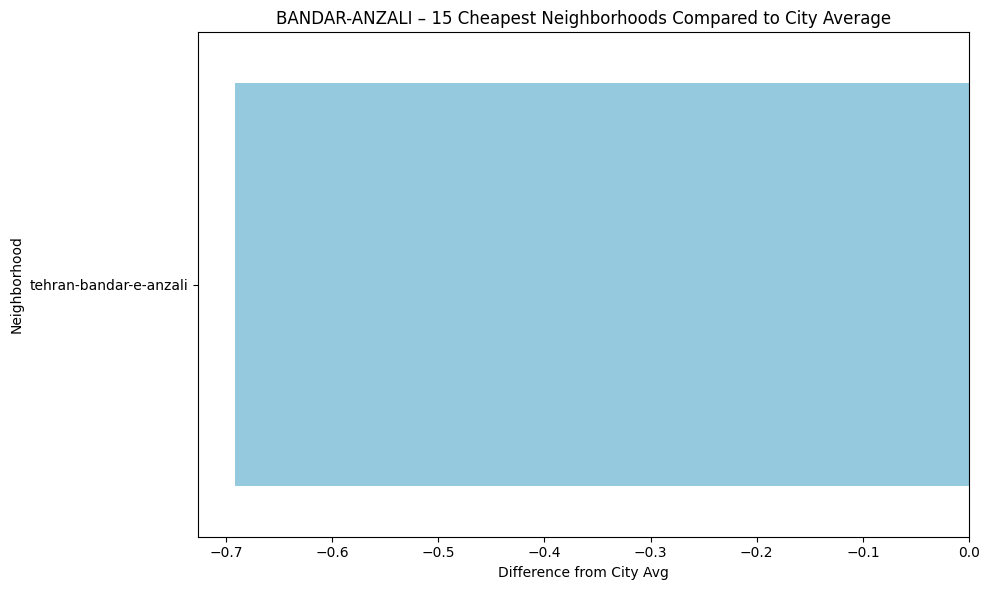

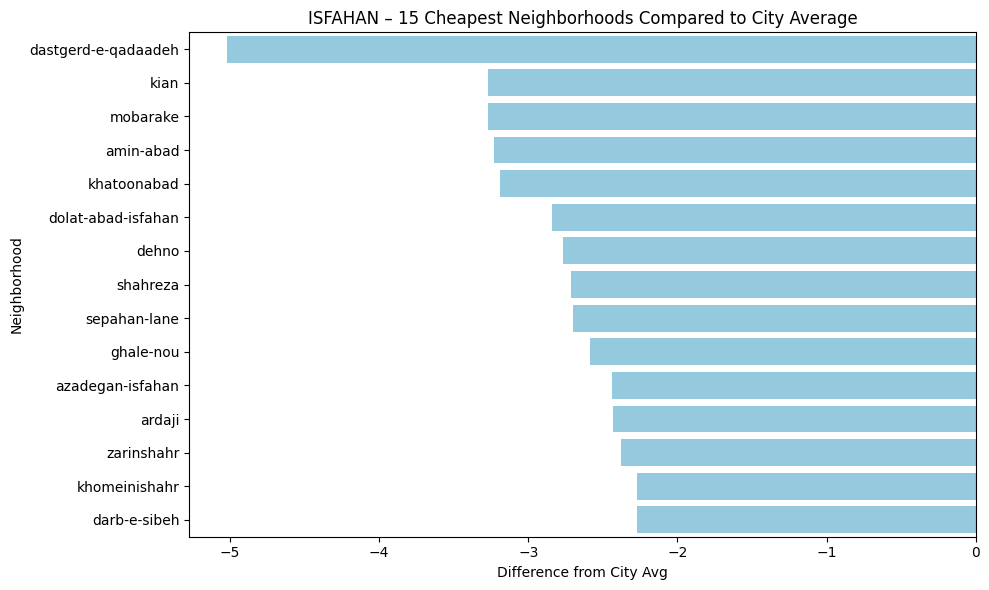

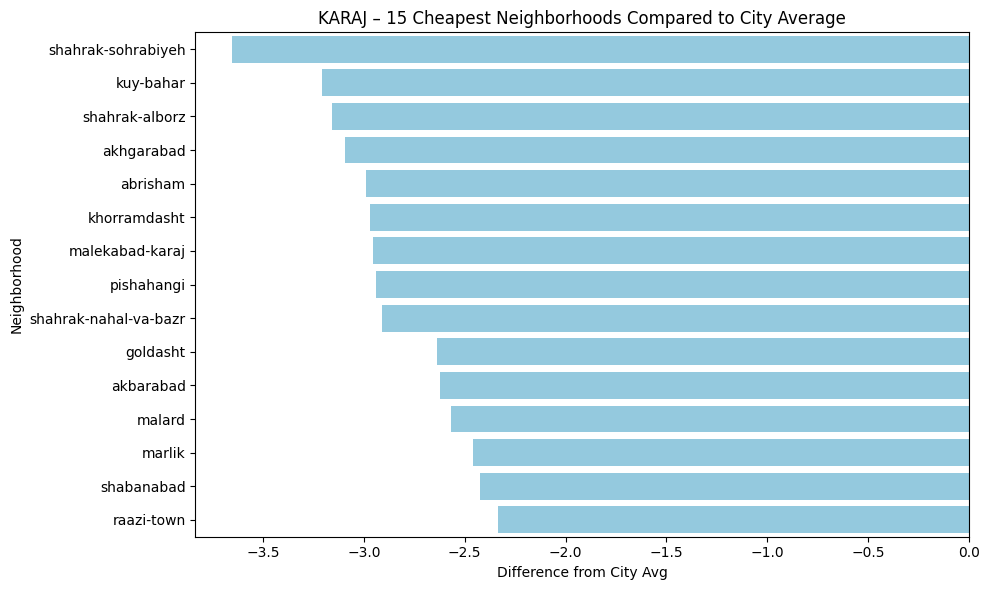

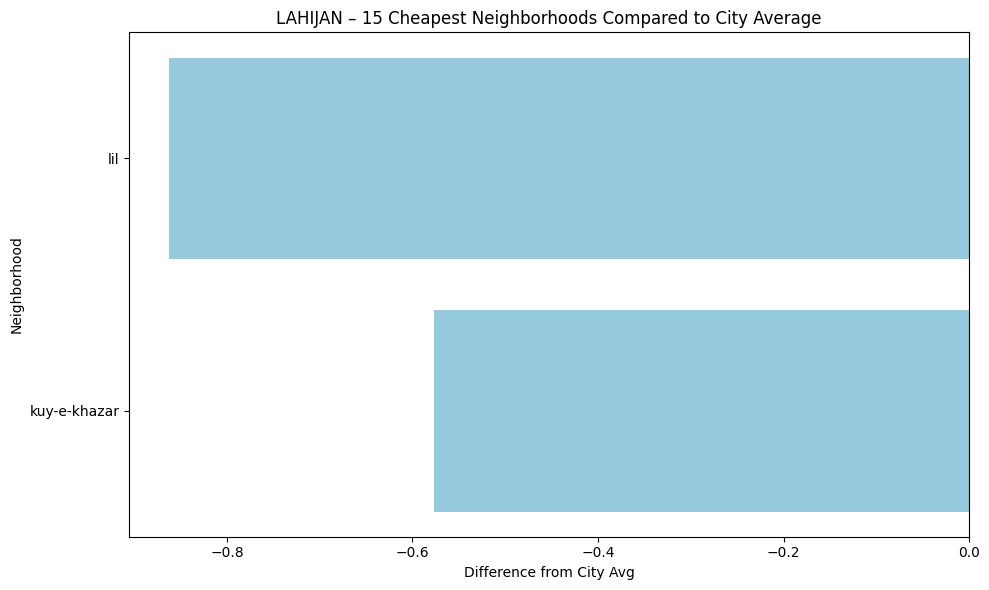

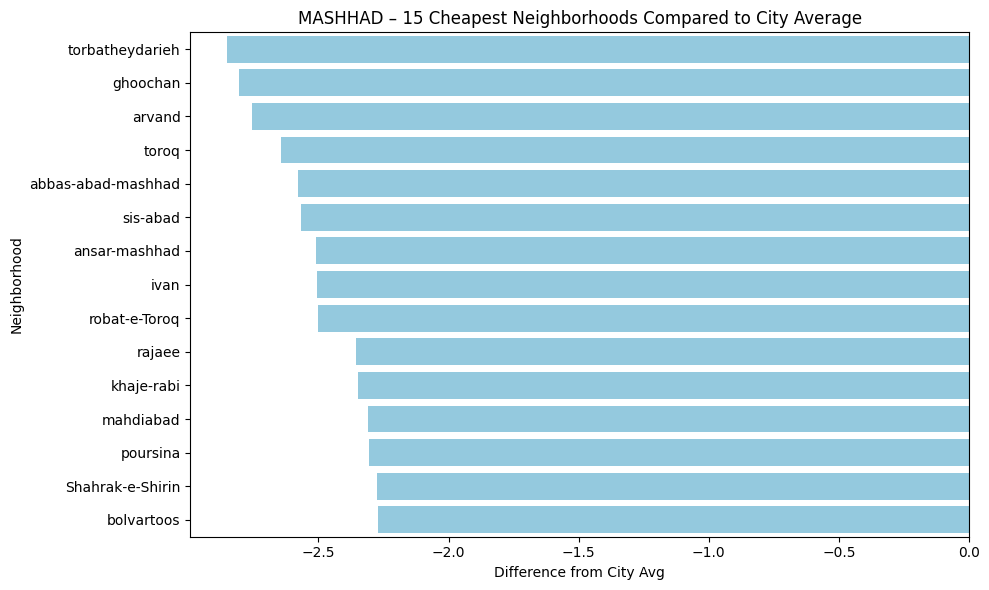

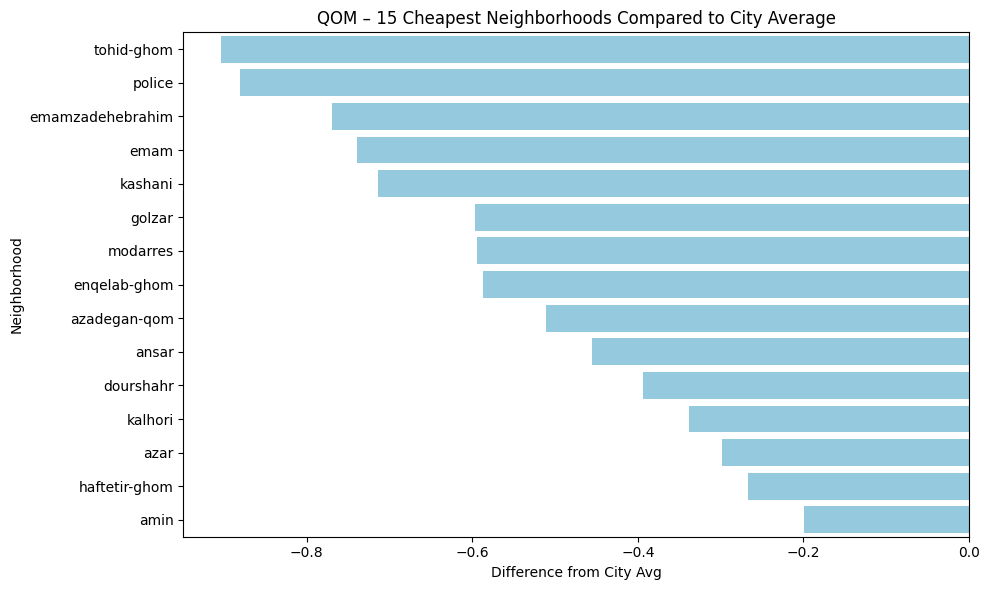

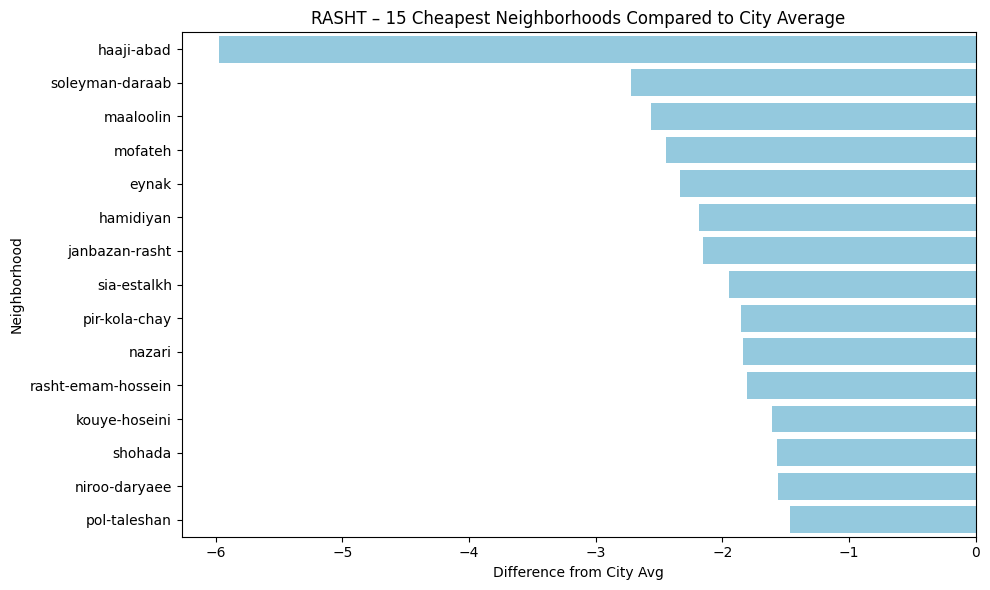

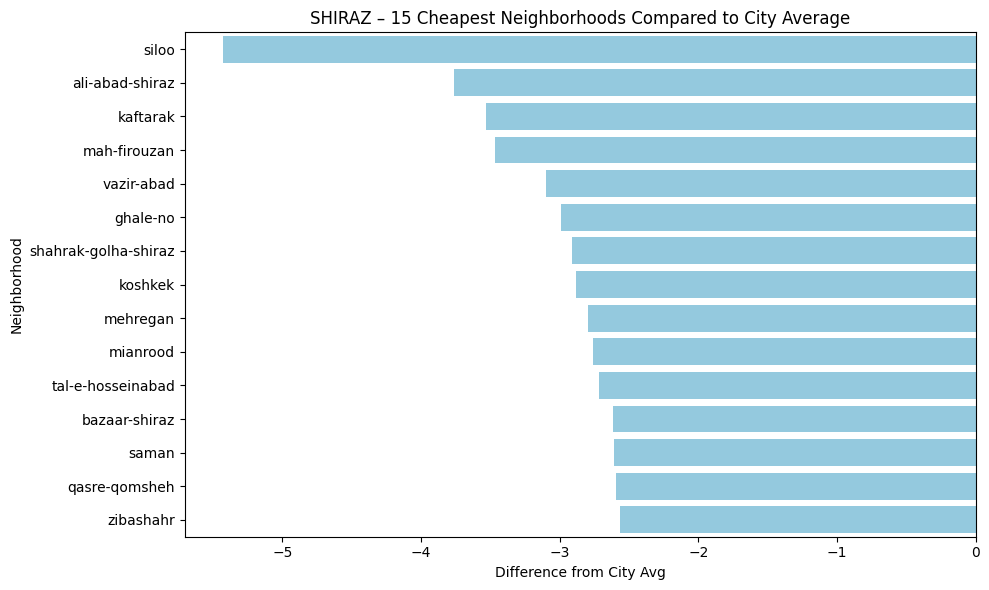

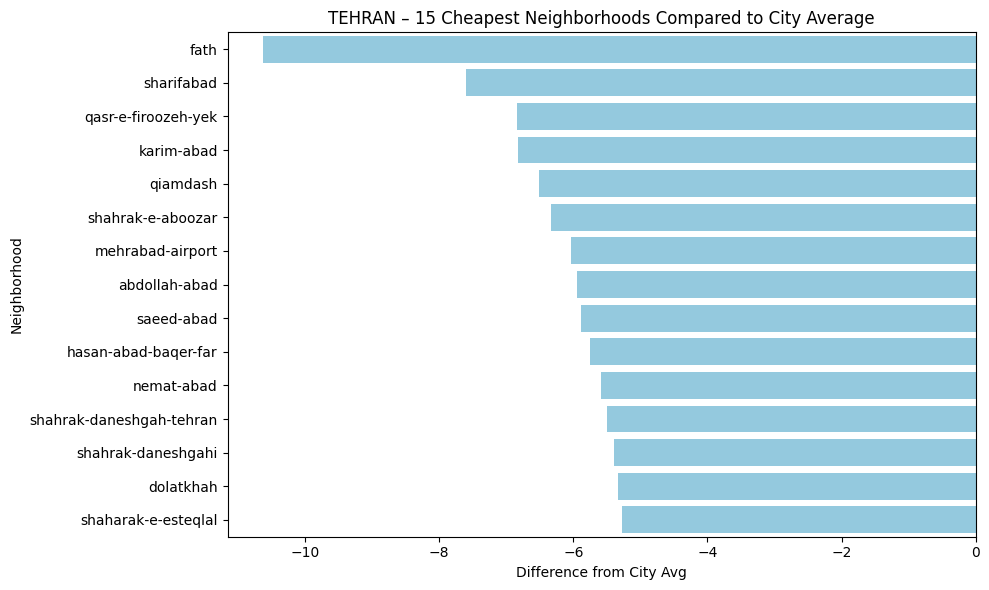

In [33]:


cities = neighbor_under_avg['city_slug'].unique()

for city in cities:
    city_data = neighbor_under_avg[neighbor_under_avg['city_slug'] == city]
    
    top15 = city_data.nsmallest(15, 'diff_from_avg_city')
    
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=top15.sort_values('diff_from_avg_city'),
        y='neighborhood_slug',
        x='diff_from_avg_city',
        color='skyblue'
    )
    
    plt.title(f'{city.upper()} – 15 Cheapest Neighborhoods Compared to City Average')
    plt.xlabel('Difference from City Avg')
    plt.ylabel('Neighborhood')
    plt.tight_layout()
    plt.savefig("14.png") 
    plt.show()



<p style="font-family:Nazanin; font-size:200%; text-align:right;color:blue;" dir="rtl">
    بخش پنجم : خوشه بندی آگهی های املاک
    
</p>

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h3><b>پیش پردازش</b> :</h3>
    <h5>
انتخاب ستون‌های مرتبط، مدیریت مقادیر گمشده، تبدیل ستون‌هایی با مقادیر بولی‌شبیه و سال‌های فارسی، کدگذاری ویژگی‌های دسته‌ای، و مقیاس‌بندی داده‌های عددی
</h5>

</div>

In [34]:
df_clustering = df.copy()

# Identify boolean-like columns and convert to 0/1, handling NaNs
boolean_cols = [col for col in df_clustering.columns if col.startswith('has_') or col == 'is_rebuilt']
for col in boolean_cols:
    if col in df_clustering.columns:
        # Ensure all values are string, map 'TRUE'/'FALSE' and fill NaNs
        df_clustering[col] = df_clustering[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0, 'NAN': 0}).fillna(0).astype(int)

# Define numerical features, including the processed 'construction_year' and boolean columns
numerical_features = ['price_per_meter', 'rent_price_per_meter', 'building_size', 'rooms_count','construction_year'] + boolean_cols

# Define categorical features
categorical_features = ['city_slug', 'cat2_slug', 'cat3_slug', 'deed_type', 'user_type', 'building_direction', 'floor_material']

# Create a new DataFrame df_clustering_processed by selecting only the defined columns
all_selected_features = numerical_features + categorical_features
df_clustering_processed = df_clustering[all_selected_features].copy()

# Handle missing values in df_clustering_processed
# Impute numerical columns with median
for col in numerical_features:
    if col in df_clustering_processed.columns:
        median_val = df_clustering_processed[col].median()
        df_clustering_processed[col].fillna(median_val, inplace=True)

# Impute categorical columns with mode
for col in categorical_features:
    if col in df_clustering_processed.columns:
        mode_val = df_clustering_processed[col].mode()[0] # .mode() can return multiple if ties
        df_clustering_processed[col].fillna(mode_val, inplace=True)

# Perform one-hot encoding on all categorical features
df_encoded = pd.get_dummies(df_clustering_processed, columns=categorical_features, drop_first=True)

# Separate numerical features for scaling
numerical_cols_for_scaling = [col for col in numerical_features if col in df_encoded.columns]

# Initialize and apply StandardScaler to numerical features
scaler = StandardScaler()
df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df_encoded[numerical_cols_for_scaling]), columns=numerical_cols_for_scaling, index=df_encoded.index)

# Concatenate scaled numerical features with one-hot encoded categorical features
df_final_clustering = pd.concat([df_scaled_numerical, df_encoded.drop(columns=numerical_cols_for_scaling)], axis=1)

print("Preprocessing complete: Rooms count converted, Boolean columns converted, NaNs handled, categorical features one-hot encoded, and numerical features scaled.")
print(f"Shape of final DataFrame for clustering: {df_final_clustering.shape}")

Preprocessing complete: Rooms count converted, Boolean columns converted, NaNs handled, categorical features one-hot encoded, and numerical features scaled.
Shape of final DataFrame for clustering: (729385, 462)


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">

<h3><b>کاهش ابعاد با استفاده از PCA</b></h3>
<h5>
 اعمال تحلیل مؤلفه‌های اصلی (<strong>PCA</strong>) بر داده‌های پیش‌پردازش‌شده و مقیاس‌بندی‌شده (<code>df_final_clustering</code>). 
</h5>
<h5>هدف تعیین تعداد مناسب مؤلفه‌ها برای حفظ واریانس کافی در داده‌ها، در عین کاهش ابعاد جهت بهبود مصورسازی و احتمالاً بهبود عملکرد خوشه‌بندی است.
</h5>
</div>


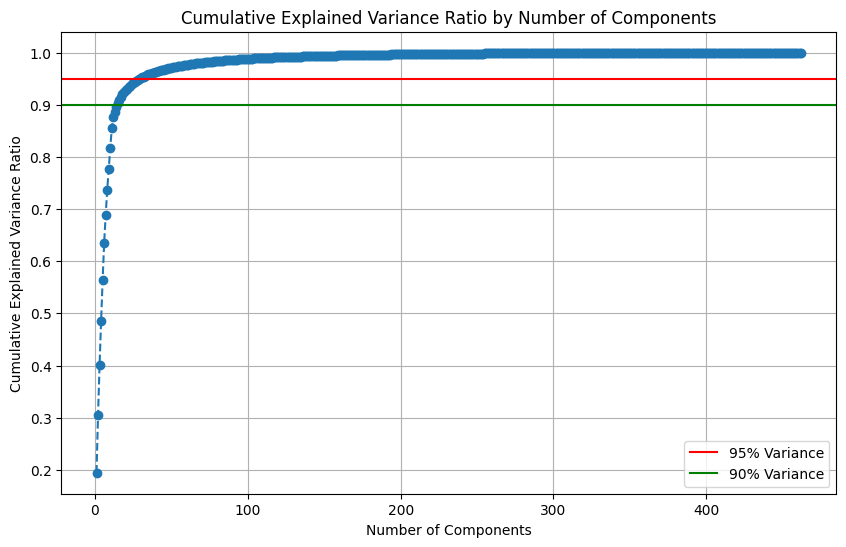

Number of components to explain 90% variance: 15
Number of components to explain 95% variance: 30
Selected number of components for PCA: 15
PCA dimensionality reduction complete.
Shape of original data: (729385, 462)
Shape of PCA transformed data: (729385, 15)


In [35]:
# Instantiate PCA without specifying n_components to analyze explained variance
pca = PCA()

# Fit PCA to the final clustering DataFrame
pca.fit(df_final_clustering)

# Calculate cumulative explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot cumulative explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance Ratio by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variance')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% Variance')
plt.legend()
plt.savefig("15.png") 
plt.show()

# Determine the number of components for 90% and 95% variance
num_components_90 = np.where(cumulative_variance >= 0.90)[0][0] + 1
num_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1

print(f"Number of components to explain 90% variance: {num_components_90}")
print(f"Number of components to explain 95% variance: {num_components_95}")

# Choose an appropriate number of components (e.g., for 90% variance) for further analysis
n_components_selected = num_components_90 # Or choose 95% based on judgment

print(f"Selected number of components for PCA: {n_components_selected}")

# Re-instantiate PCA with the selected number of components
pca_final = PCA(n_components=n_components_selected)

# Fit and transform the data
df_pca_transformed = pca_final.fit_transform(df_final_clustering)

# Create a new DataFrame with the PCA-transformed data
df_pca = pd.DataFrame(data=df_pca_transformed, columns=[f'PC{i+1}' for i in range(n_components_selected)])

print("PCA dimensionality reduction complete.")
print(f"Shape of original data: {df_final_clustering.shape}")
print(f"Shape of PCA transformed data: {df_pca.shape}")

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h5><b>خوشه بندی</b></h2>
<h5>گام اول تعیین تعداد بهینه خوشه </h5>
<h5 style="direction: rtl; text-align: right;">
تعیین تعداد بهینه خوشه‌ها (<strong>k</strong>) با استفاده از روش‌های <strong>Elbow</strong> و <strong>امتیاز Silhouette</strong> بر روی داده‌های تبدیل‌شده با <code>PCA</code> (<code>df_pca</code>).
</h5>

</div>



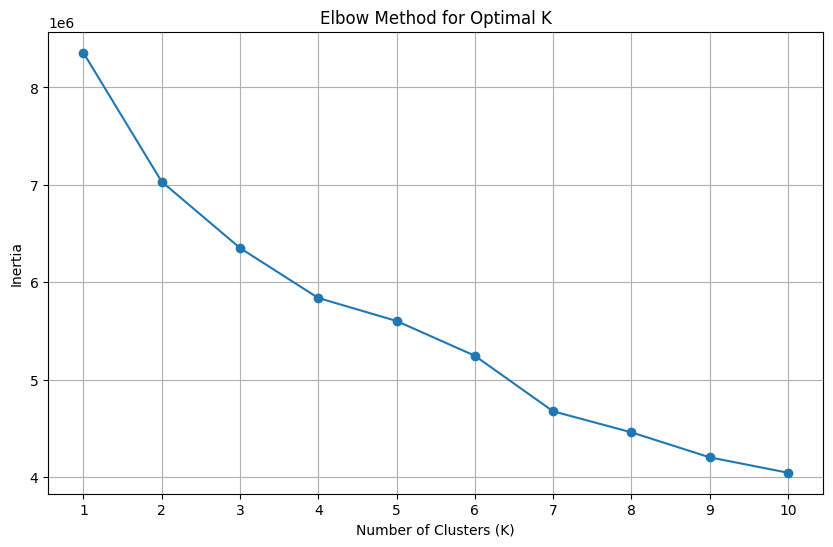

In [36]:
# Elbow Method
inertia_values = []

# Loop through a range of possible cluster numbers
# It's common to start from 1, but for KMeans, usually 2 is the minimum for meaningful clusters
for i in range(1, 11): # Testing k from 1 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df_pca)
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.savefig("16.png") 
plt.show()


In [ ]:
#****** it might take long time to Run! so be carful if you want to run This cell! *******

# Silhouette Score Method
silhouette_scores = []

# Loop through a range of possible cluster numbers (start from 2 for Silhouette Score)
for i in range(2, 10): # Testing k from 2 to 10
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    kmeans.fit(df_pca)
    cluster_labels = kmeans.predict(df_pca)
    score = silhouette_score(df_pca, cluster_labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score results
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 10))
plt.grid(True)
plt.savefig("17.png") 
plt.show()

# Determine the optimal number of clusters based on both methods
# Elbow method: Look for the 'elbow' point where the inertia starts to decrease at a slower rate.
# From the plot, it seems the elbow is around K=3 or K=4.

# Silhouette method: Look for the highest silhouette score.
optimal_k_silhouette = range(2, 10)[np.argmax(silhouette_scores)]

print(f"Silhouette Scores for K=2 to 10: {silhouette_scores}")
print(f"The optimal number of clusters based on Silhouette Score is: {optimal_k_silhouette}")


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">

<h5><b>اجرای خوشه‌بندی K-Means</b> </h5>
<h5>
اجرای الگوریتم خوشه‌بندی <strong>K-Means</strong> بر روی داده‌های کاهش‌بُعد یافته (<code>df_pca</code>) با استفاده از تعداد خوشه‌های بهینه <strong>K=4</strong> که در مرحله قبل شناسایی شده بود. سپس، تخصیص هر نقطه داده به خوشه مربوطه.اکنون که تعداد بهینه خوشه‌ها (<strong>K=4</strong>) تعیین شده است، می‌توان الگوریتم <strong>K-Means</strong> را بر روی داده‌های تبدیل‌شده با PCA (<code>df_pca</code>) اجرا کرد. برچسب‌های خوشه به دست آمده به هر دو دیتافریم <code>df_pca</code> و <code>df_clustering</code> (که شامل ویژگی‌های اصلی و پیش‌پردازش‌شده است) اضافه خواهند شد تا امکان <strong>تصویری‌سازی</strong> و <strong>تفسیر خوشه‌ها</strong> بر اساس ویژگی‌های اصلی داده فراهم شود.
</h5>

</div>


In [ ]:
# Instantiate KMeans with n_clusters=4 (optimal K from previous step) and random_state for reproducibility
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Fit the KMeans model to the PCA-transformed data
kmeans.fit(df_pca)

# Predict the cluster labels for df_pca
cluster_labels = kmeans.predict(df_pca)

# Assign cluster labels to df_pca
df_pca['cluster_label'] = cluster_labels

# Assign the same cluster labels to the original preprocessed DataFrame (df_clustering)
df_clustering['cluster_label'] = cluster_labels

print("K-Means clustering applied and cluster labels assigned to df_pca and df_clustering.")
print(f"First 5 cluster labels in df_pca: {df_pca['cluster_label'].head().tolist()}")
print(f"First 5 cluster labels in df_clustering: {df_clustering['cluster_label'].head().tolist()}")

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">

<h5><b>مصورسازی و تفسیر خوشه‌ها</b></h5>

</div>




In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster_label',
    data=df_pca,
    palette='viridis',
    alpha=0.6,
    s=10 # Smaller dot size for better visualization of large datasets
)
plt.title('PCA Clustering Visualization (PC1 vs PC2)', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.savefig("18.png") 
plt.show()


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h5 ><b>تفسیر خوشه ها</b></h5>
<h5>
    اکنون میانگین مقادیر ویژگی های عددی را برای هر خوشه بدست می آوریم تا ویژگی های هر خوشه بهتر مشخص شود
</h5>


In [ ]:
numerical_features_to_analyze = ['price_per_meter', 'rent_price_per_meter', 'building_size', 'rooms_count', 'construction_year'] + boolean_cols

# Calculate mean values for numerical features for each cluster
cluster_numerical_means = df_clustering.groupby('cluster_label')[numerical_features_to_analyze].mean()

print("Mean values of numerical features per cluster:")
print(cluster_numerical_means)


In [ ]:
print("Top categorical features per cluster (mode or value counts):")
for cluster_id in sorted(df_clustering['cluster_label'].unique()):
    print(f"\n--- Cluster {cluster_id} ---")
    cluster_data = df_clustering[df_clustering['cluster_label'] == cluster_id]
    for col in categorical_features:
        if col in cluster_data.columns:
            print(f"  {col}:")
            print(cluster_data[col].value_counts(normalize=True).head(5))


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
    
<h3><strong>تفسیر خوشه‌ها:</strong></h3>
<h4><strong>بر اساس تحلیل ویژگی‌های عددی و دسته‌ای در هر خوشه، می‌توان بخش‌های مختلف بازار املاک را به شکل زیر تعریف کرد:</strong></h4>
<ul>
<li><strong>خوشه 0: آپارتمان‌های میان‌رده شهری (با تمرکز بر مشاوران املاک)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> قیمت متوسط هر متر، اجارهٔ کم هر متر (احتمالاً به دلیل تمرکز بیشتر بر املاک فروش یا بازده اجاره کم نسبت به قیمت)، متراژ نسبتاً کوچک (حدود ۴۰۰ متر)، ۱–۲ اتاق، سال ساخت قدیمی‌تر (حدود ۱۳۹۰). حضور زیاد امکانات پایه مثل بالکن، آسانسور، انباری و پارکینگ، اما امکانات لوکس بسیار کم.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> عمدتاً در تهران، کرج، مشهد. تمرکز بر «مسکونی-فروش» و «مسکونی-اجاره». غالباً سند «تک‌برگی». عمدتاً توسط «مشاور املاک» ثبت می‌شوند. جهت‌های شمال/جنوب و کف‌پوش سرامیک رایج است. نوع ملک بیشتر «سایر» و سپس «جنگلی».</li>
        <li><strong>تفسیر:</strong> این خوشه نمایانگر املاک مسکونی میان‌رده در شهرهای بزرگ است که عمدتاً آپارتمانی و توسط مشاوران املاک مدیریت می‌شوند. اختلاف کم اجاره نسبت به قیمت فروش ممکن است نشان‌دهنده‌ی بازار خرید فعال‌تر یا نبود داده‌های قوی در بخش اجاره باشد.</li>
    </ul>
</li>

<li><strong>خوشه 1: ترکیبی تجاری/مسکونی (نوسان زیاد قیمت و اجاره)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> قیمت متوسط هر متر، اما <em>اجارهٔ بسیار بالا</em> (۱۳۳۸۰۴ که احتمال وجود نقاط پرت بسیار بالا یا املاک خاص تجاری/کوتاه‌مدت را نشان می‌دهد). بزرگ‌ترین متراژها (حدود ۹۰۰۰ متر)، اتاق کم (حدود ۱)، سال ساخت جدیدتر (۱۳۹۲). کم‌ترین حضور امکانات پایه.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> پراکندگی در شهرهای بزرگ (تهران، مشهد، اصفهان). ترکیبی از فروش/اجاره مسکونی و تجاری و همچنین اجاره کوتاه‌مدت. حضور زیاد «زمین-قدیمی» و «مغازه-اجاره». تنوع در نوع سند. غالباً توسط مشاور املاک ثبت می‌شود. کف‌پوش بیشتر سرامیک، سپس موکت و موزاییک.</li>
        <li><strong>تفسیر:</strong> این خوشه ترکیبی از املاک بزرگ، زمین‌های بایر، و املاک تجاری با نرخ اجارهٔ بسیار متغیر است. وجود اجاره‌های فوق‌العاده بالا احتمالاً ناشی از قراردادهای تجاری خاص یا داده‌های پرت می‌باشد.</li>
    </ul>
</li>

<li><strong>خوشه 2: آپارتمان‌های لوکس شهری (با تمرکز بر مشاوران املاک)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> قیمت متوسط هر متر (مشابه خوشه 0) اما تعداد اتاق‌ها بیشتر (۲–۳)، سال ساخت جدیدتر (۱۳۹۶)، حضور زیاد امکانات پایه. اجاره هر متر متوسط اما بیشتر از خوشه 0 و بسیار کمتر از خوشه 1.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> مشابه خوشه 0 اما تمرکز بیشتر بر املاک مسکونی فروش/اجاره در آپارتمان‌ها و ویلاها. سند تک‌برگی، ثبت توسط مشاور املاک، جهت‌های شمال/جنوب، کف‌پوش عمدتاً سرامیک و سپس سنگ. نوع ملک «جنگلی» بسیار زیاد (۶۷٪).</li>
        <li><strong>تفسیر:</strong> این خوشه نمایانگر املاک مسکونی لوکس‌تر و نسبتاً جدید در شهرهای بزرگ است. تعداد اتاق بیشتر، سال ساخت جدید و امکانات بالا، نشان‌دهنده‌ی جذابیت بیشتر برای خریداران و مستأجران است.</li>
    </ul>
</li>

<li><strong>خوشه 3: بازار ویلا/زمین شمال (پر از امکانات رفاهی)</strong>
    <ul>
        <li><strong>ویژگی‌های عددی:</strong> کم‌ترین قیمت هر متر، کم‌ترین اجاره هر متر، متراژ زیاد (حدود ۳۱۴۰ متر)، بیشترین تعداد اتاق (۲–۳)، جدیدترین سال ساخت (۱۳۹۹). حضور بالا در امکانات لوکس مثل نگهبانی، باربیکیو، استخر، جکوزی و سونا. تقریباً ۱۰۰٪ دارای آب، برق، گاز.</li>
        <li><strong>ویژگی‌های دسته‌ای:</strong> متمرکز در شهرهای شمالی: چمستان، نور، محمودآباد، نوشهر، رامسر. تمرکز زیاد بر «مسکونی-فروش» و «اجاره موقت» ویلا. سند تک‌برگی، ثبت توسط مشاور املاک. کف‌پوش سرامیک. نوع ملک «جنگلی» و سپس «ساحلی».</li>
        <li><strong>تفسیر:</strong> این خوشه دقیقاً نشان‌دهنده بازار ویلاهای شمال و املاک گردشگری است. امکانات لوکس، متراژ بالا و سال ساخت جدید، این املاک را به گزینه‌هایی مناسب اقامت تفریحی یا سرمایه‌گذاری تبدیل می‌کند.</li>
    </ul>
</li>
</ul>

<h3><strong>مقایسه با انتظارات:</strong></h3>
<h5>نمایش تصویری خوشه‌ها نشان می‌دهد که تفکیک مناسبی به‌خصوص در خوشه 3 وجود دارد. روش‌های Elbow و Silhouette مقدار ۳ یا ۴ را پیشنهاد می‌کردند و K=4 توانسته تقسیم‌بندی معناداری ایجاد کند. تفسیرها نیز با انتظار ما از بازار املاک، از نظر موقعیت، نوع ملک، سن بنا، امکانات و قیمت سازگار است.</h5>
</div>

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">

<h2>خلاصه:</h2>

<h3>یافته‌های کلیدی تحلیل داده</h3>

<ul>
<li><strong>کارآمدی کاهش ابعاد (PCA):</strong> استفاده از تحلیل مؤلفه‌های اصلی به‌طور مؤثر ابعاد داده را کاهش داد و امکان نمایش واضح تفکیک خوشه‌ها در یک فضای دو‌بعدی را فراهم کرد. نمودار پراکندگی PC1 در برابر PC2 گروه‌بندی‌های مشخصی را نشان داد که تأیید می‌کند مقدار K=4 تفکیک‌های معناداری در بازار ایجاد کرده است.</li>

<li><strong>خوشه 0: آپارتمان‌های میان‌رده شهری:</strong> این بخش شامل املاک مسکونی، عمدتاً آپارتمان‌ها، در شهرهای بزرگی مانند تهران و کرج است. ویژگی‌های آن شامل قیمت متوسط، بازده اجاره پایین‌تر نسبت به قیمت فروش، متراژ حدود ۴۰۰ متر، ۱ تا ۲ اتاق و سال ساخت قدیمی‌تر (حدود ۲۰۱۱) است. این املاک معمولاً دارای امکانات پایه بوده و عمدتاً توسط مشاوران املاک مدیریت می‌شوند.</li>

<li><strong>خوشه 1: املاک تجاری/مسکونی متنوع با نوسان شدید اجاره:</strong> این خوشه نشان‌دهنده مجموعه‌ای از املاک بزرگ، احتمالاً شامل فضاهای تجاری یا زمین‌های بایر است، با میانگین اجارهٔ هر متر بسیار بالا (۱۳۳٬۸۰۴ دلار). این املاک بیشترین متراژ متوسط (حدود ۹۰۰۰ متر)، تعداد اتاق کم (حدود ۱) و سال ساخت جدیدتر (حدود ۲۰۱۳) دارند. این تنوع نشان‌دهنده بازاری با تمرکز سرمایه‌گذاری بالا و فعالیت‌های تخصصی تجاری است.</li>

<li><strong>خوشه 2: آپارتمان‌های لوکس شهری:</strong> این بخش شامل آپارتمان‌ها و خانه‌های مسکونی جدیدتر و سطح‌بالا در شهرهای بزرگ مانند تهران، مشهد و کرج است. آن‌ها دارای تعداد اتاق بیشتر (۲–۳)، سال ساخت جدیدتر (حدود ۲۰۱۷)، و مجموعه کامل امکانات پایه هستند. این ویژگی‌ها نشان‌دهنده جذابیت بیشتری نسبت به خوشه 0 بوده و غالباً توسط مشاوران املاک مدیریت می‌شوند.</li>

<li><strong>خوشه 3: بازار ویلا/زمین شمال:</strong> این خوشه عمدتاً در شهرهای شمالی و گردشگری قرار دارد و شامل ویلاها، خانه‌های تفریحی یا زمین است. این املاک دارای جدیدترین سال ساخت (حدود ۲۰۲۰)، بیشترین تعداد اتاق (۲–۳)، و متراژ بالاتر (حدود ۳۱۴۰ متر) هستند. وجود امکانات لوکس مانند استخر، جکوزی، سونا و نگهبانی از ویژگی‌های بارز این خوشه است، که معمولاً در دسته‌های فروش مسکونی یا اجاره موقت ارائه می‌شوند.</li>
</ul>

<h3>بینش‌ها و گام‌های بعدی</h3>

<ul>
<li>بخش‌های مختلف شناسایی‌شده، پایه محکمی برای استراتژی‌های بازاریابی هدفمند و برنامه‌ریزی توسعه فراهم می‌کنند و به ذینفعان امکان می‌دهند روی نیازهای مشتریان و انواع خاصی از املاک تمرکز کنند (مثلاً ویلاهای لوکس شمال در مقابل آپارتمان‌های میان‌رده شهری).</li>

<li>نیاز به بررسی بیشتر درباره اجاره‌های بسیار بالا در خوشه 1 وجود دارد تا مشخص شود این نرخ‌ها ناشی از قراردادهای تجاری تخصصی، اجاره‌های کوتاه‌مدت یا داده‌های پرت هستند؛ زیرا این موارد می‌توانند تأثیر چشمگیری بر ارزش‌گذاری بازار و تصمیمات سرمایه‌گذاری داشته باشند.</li>
</ul>

</div>


<p style="font-family:Nazanin; font-size:200%; text-align:right;color:blue;" dir="rtl">
    بخش ششم : مدل سازی قیمت
    
</p>

In [ ]:
!jupyter nbconvert --to python Divar_cleaning.ipynb


In [ ]:
import Divar_cleaning as dclean

In [ ]:
data = pd.read_csv('sampled_data.csv',encoding = 'utf-8', engine='python')

In [ ]:
#Cleaned Data as df

df = dclean.cleaning_data(data)

# after cleaning using cleaning_data function, there is no boolean value since thay have been converted to int
# So, we have numeric, categorical and text columns

In [ ]:
df.shape

<a id = "rf"></a>
<h1  style="color:blue; font-family:Nazanin;" dir="rtl">1- پیش‌پردازش </h1>

<p style="font-family:Nazanin; font-size:140%; text-align:right;" dir="rtl">
  متغیرهای موثر در قیمت آگهی‌ها را با تحلیل داده انتخاب کنید. متغیرهای انتخاب شده را به ساختار مناسب برای مدلسازی تبدیل کنید. به عنوان نمونه اگر نیاز به نرمال‌سازی و تغییر متغیرهای دیگر وجود دارد اعمال کنید. اگر مقادیر متناقض، ناموجود یا پرت در هر یک از متغیرها ممکن است مخل مدلسازی شود درباره آن شیوه درست مواجهه با آن تصمیم‌گیری کنید. 
</p>

# In this section, we only need to work on Numerical and Categorical columns (not text) 

In [ ]:
numeric_cols, categorical_cols, bool_cols, text_cols = dclean.detect_column_types(df)

# Making X and Y ready

In [ ]:
df_pre = pd.DataFrame()

for col in numeric_cols:
    df_pre[col] = df[col]

#Using LabelEncoding
for col in categorical_cols:    
    encoder = LabelEncoder()
    df_pre[col] = df[col]
    df_pre[f'{col}_encoded'] = encoder.fit_transform(df[col])

#Using OneHotEncoding
# for col in categorical_cols:    
#     encoder = OneHotEncoder(sparse_output=False)
#     df_pre[col] = df[col]
#     df_pre[f'{col}_encoded'] = encoder.fit_transform(df[col])

for col in categorical_cols:
    le = LabelEncoder()
    df_pre[col] = df[col]
    df_pre[f'{col}_encoded'] = le.fit_transform(df[col])

    
target_col = 'value_rent_or_price'

y = df_pre[target_col]


# Preparing X for Models requir Encoding (All fuatures should be numeric) >>> Regression, KNN, SVM, Neural Network

In [ ]:
cat_encoded_cols = [c + '_encoded' for c in categorical_cols]
X_Enc = df_pre [numeric_cols + cat_encoded_cols].drop(columns = target_col)

# Makeing X_Enc Standard

In [ ]:
scaler = StandardScaler()
X_Enc = scaler.fit_transform(X_Enc)


# Preparing X for Models NOT requir Encoding >>> DesicionTree, RandomForest

In [ ]:
X_Tree = df_pre[numeric_cols + categorical_cols].drop(columns = target_col)

In [ ]:
print("X_Enc shape:", X_Enc.shape)
print("X_Tree shape:", X_Tree.shape)
print("Y shape:", y.shape)


# Creating Train, Validation and Test Dataset (Linear Models) - For X_Enc

In [ ]:
# Creating a testing dataset of size 0.2 times the whole dataset  
X_train, X_test, y_train, y_test = train_test_split( X_Enc, y, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

# Creating a validation dataset of size 0.2 times the whole train Data  
X_train, X_val, y_train, y_val = train_test_split(  X_train, y_train, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

In [ ]:
print("Shape of training set:")
print(X_train.shape)  
print(y_train.shape)  

print("Shape of validation set:")
print(X_val.shape)  
print(y_val.shape)  

print("Shape of test set:")
print(X_test.shape)  
print(y_test.shape)  

<a id = "rf"></a>
<h1  style="color:blue; font-family:Nazanin;" dir="rtl">2- مدلسازی</h1>


<p style="font-family:Nazanin; font-size:140%; text-align:right;" dir="rtl">
با استفاده از متغیرهای موثر دست کم سه مدل با شیوه‌های گوناگون مانند رگرسیون خطی، رگرسیون درخت تصمیم، رگرسیون با knn، شبکه عصبی، روش‌های یادگیری گروهی مثل جنگل تصادفی و … برای پیش‌بینی قیمت آگهی بسازید و با تحلیل نتایج بهترین مدل را انتخاب کنید. 
</p>

# Learning Models (Linear with X_Enc)

In [ ]:
# Define Models contains Model Name, Y_Pred_Val and Y_Pred_Test
models = {}


# #1 K-Nearest Neighbors

In [ ]:
knn = KNeighborsRegressor(n_neighbors = 5) 
knn.fit(X_train, y_train)
models['KNN'] = [knn, knn.predict(X_val), knn.predict(X_test)]

# Do we need to use Best Approach to find n_neighbors?

# #2 Linear Regression

In [ ]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)
models['Linear Regression'] = [linreg, linreg.predict(X_val), linreg.predict(X_test)]

# #3 Regularization

In [ ]:
# Lasso
lasso = Lasso(alpha = 5)
lasso.fit(X_train, y_train)
models['Lasso'] = [lasso, lasso.predict(X_val), lasso.predict(X_test)]


# Ridge
ridge = Ridge(alpha = 5)
ridge.fit(X_train, y_train)
models['Ridge'] = [ridge, ridge.predict(X_val), ridge.predict(X_test)]

# #4 Gradient Boosting

In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)
models[' GradientBoostingRegressor'] = [gb, gb.predict(X_val), gb.predict(X_test)]

# #5 XGBoost
# (Sequential - tree-based algorithm - Require Encoding (new version not))
# Using GridSearchCV

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

#Number of Trees (Number of Boosing)
xgb = XGBRegressor(
    objective='reg:squarederror'
)


#n_estimaor_options = [80,90,95,100,150,200,250,300]
#max_depth_options = [2,4,6,8,10,12,14,16,18,20, 26]
#learning_rate = [0.01, 0.05, 0.1]

n_estimaor_options = [300]
max_depth_options = [10]
learning_rate = [0.05]

param_grid = {
    'n_estimators': n_estimaor_options,
    'max_depth': max_depth_options,
    'learning_rate': learning_rate
#    'gamma': [0, 1, 5],
}

grid_s = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)
grid_s.fit(X_train, y_train)

print("Best parameters:", grid_s.best_params_)
print("Best score:", grid_s.best_score_)

best_model = grid_s.best_estimator_

models['XGBoost'] = [best_model, best_model.predict(X_val), best_model.predict(X_test)]


# #6 Neural Network

In [ ]:
nn = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    max_iter=500,
    random_state=42,
    solver = 'adam'
        )
nn.fit(X_train, y_train)
models['Neural Network'] = [nn, nn.predict(X_val), nn.predict(X_test)]

# Creating Train, Validation and Test Dataset (Tree-Based Model) - For X_Tree

!!!!! Error for Decision Tree and Random Forest

In [ ]:
# Creating a testing dataset of size 0.2 times the whole dataset  
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_Tree, y, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

# Creating a validation dataset of size 0.2 times the whole train Data  
X_train_t, X_val_t, y_train_t, y_val_t = train_test_split(X_train_t, y_train_t, 
                                                    test_size = 0.2, 
                                                    random_state = 10
                                                   )  

# #7 Decision Tree

In [ ]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = [dt, dt.predict(X_val), dt.predict(X_test)]

# #8 Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    min_samples_split=10,
    random_state=42
)
rf.fit(X_train, y_train)
models['Random Forest'] = [rf, rf.predict(X_val), rf.predict(X_test)]

# Evaluation

In [ ]:
evaluation_results = {}

y_test_f = y_test
for name, model in models.items():
   # y_test_f = y_test_t if name in ['Decision Tree', 'Random Forest'] else y_test

    # comparing y_test_f and model.predict(X_test_)
    mse = mean_squared_error(y_test_f, model[2])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_f, model[2])
    r2 = r2_score(y_test_f, model[2])
    mape = np.mean(np.abs((y_test_f -  model[2]) / (y_test_f + 1e-10))) * 100
    
    evaluation_results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape
    }

# Plot the results

In [ ]:
!pip install arabic_reshaper

In [ ]:
!pip install python-bidi


In [ ]:
import arabic_reshaper
import bidi.algorithm

def text_fa(x):
    x = arabic_reshaper.reshape(x)
    x = bidi.algorithm.get_display(x)
    return x

In [ ]:
plt.figure(figsize=(8,8))

y_test_f = y_test
for name, model in models.items():    
   # y_test_f = y_test_t if name in ['Decision Tree', 'Random Forest'] else y_test
    
    plt.scatter(
        y_test_f, 
        model[2], 
        alpha=0.5, 
        s=15,       # نقطه کوچیک برای کم شدن شلوغی
        label=name
    )

plt.xlabel(text_fa('مقادیر حقیقی'))
plt.ylabel(text_fa('مقادیر پیش‌بینی‌شده'))
plt.legend()
plt.grid(True)
plt.savefig("20.png") 
plt.show()
    
# max_val = max( y_test_f.max(), max([pred.max() for pred in models.values[2]]))
# min_val = min(y_test_f.min(), min([pred.min() for pred in models.values[2]]))
# plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

# plt.xlabel(text_fa('مقادیر حقیقی'))
# plt.ylabel(text_fa('مقادیر پیش‌بینی‌شده'))
# plt.title(text_fa('مقادیر حقیقی/ مقادیر پیش‌بینی‌شده برای همه مدل‌ها '))
# plt.legend()
# plt.grid(True)
# plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(text_fa('مقایسه عملکرد مدل‌ها'), fontsize=16, fontweight='bold')


evaluation_results_df = pd.DataFrame(evaluation_results).T

rmse_sorted = evaluation_results_df['RMSE'].sort_values()
axes[0, 0].barh(rmse_sorted.index, rmse_sorted.values, color='skyblue')
axes[0, 0].set_title(text_fa('RMSE (کمتر بهتر)'))
axes[0, 0].set_xlabel('RMSE')

r2_sorted = evaluation_results_df['R2'].sort_values(ascending=False)
axes[0, 1].barh(r2_sorted.index, r2_sorted.values, color='lightgreen')
axes[0, 1].set_title(text_fa('R² Score (بیشتر بهتر)'))
axes[0, 1].set_xlabel('R²')

mae_sorted = evaluation_results_df['MAE'].sort_values()
axes[1, 0].barh(mae_sorted.index, mae_sorted.values, color='lightcoral')
axes[1, 0].set_title(text_fa('MAE (کمتر بهتر)'))
axes[1, 0].set_xlabel('MAE')

mape_sorted = evaluation_results_df['MAPE'].sort_values()
axes[1, 1].barh(mape_sorted.index, mape_sorted.values, color='plum')
axes[1, 1].set_title(text_fa('MAPE % (کمتر بهتر)'))
axes[1, 1].set_xlabel('MAPE %')

plt.tight_layout()
plt.savefig("21.png") 
plt.show()

# Choose Best Model

| Metric                                    | Goal             | Notes                                                     |
| ----------------------------------------- | ---------------- | --------------------------------------------------------- |
| **MAE** (Mean Absolute Error)             | Lower is better  | Average absolute error, same unit as target (e.g., price) |
| **RMSE** (Root Mean Squared Error)        | Lower is better  | Penalizes large errors more than MAE                      |
| **MAPE** (Mean Absolute Percentage Error) | Lower is better  | Percentage error, good for relative comparison            |
| **R²** (Coefficient of Determination)     | Higher is better | Explains how much variance is captured by the model       |


In [ ]:
evaluation_results_df['MAE_rank'] = evaluation_results_df['MAE'].rank(ascending=True)
evaluation_results_df['RMSE_rank'] = evaluation_results_df['RMSE'].rank(ascending=True)
evaluation_results_df['MAPE_rank'] = evaluation_results_df['MAPE'].rank(ascending=True)

evaluation_results_df['R2_rank'] = evaluation_results_df['R2'].rank(ascending=False)

evaluation_results_df['Overall_rank'] = evaluation_results_df[['MAE_rank','RMSE_rank','MAPE_rank','R2_rank']].sum(axis=1)

# Best model = lowest Overall_rank
best_model_name = evaluation_results_df['Overall_rank'].idxmin()
best_model_score = evaluation_results_df.loc[best_model_name, 'Overall_rank']

print(text_fa('بهترین مدل برای داده‌های املاک: ') )
print (best_model_name)


<a id = "rf"></a>
<h1  style="color:blue; font-family:Nazanin;" dir="rtl">تحلیل نتایج: </h1>



<p style="font-family:Nazanin; font-size:140%; text-align:right;" dir="rtl">
   با استفاده از مدل‌سازی انجام شده، نتایج به دست آمده را با توجه به رابطه قیمت و ویژگی‌ها ملک، به سه دست گران (over-value)، مناسب (normal) و ارزان (under-value) تقسیم کنید.
</p>

In [ ]:
y_test_f = y_test
# if best_model_name in ['Decision Tree', 'Random Forest']:
#     y_test_f = y_test_t
y_pred = models[best_model_name][2]

df_analys = pd.DataFrame({
    'Actual': y_test_f,
    'Predicted': y_pred
})

df_analys['Residual'] = df_analys['Actual'] - df_analys['Predicted']
residual_std = df_analys['Residual'].std()

df_analys['Category'] = df_analys.apply(
    lambda r: 'Under-value' if r['Residual'] > residual_std 
    else 'over-value' if r['Residual'] < -residual_std
    else 'Normal',
    axis = 1
)
print(df_analys['Category'].value_counts())


# Plot Residual and Thresholds

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(df_analys)), df_analys['Residual'], alpha=0.6)

plt.axhline(residual_std, color='green', linestyle='--', label='+1σ')
plt.axhline(-residual_std, color='red', linestyle='--', label='-1σ')
plt.axhline(0, color='black', linewidth=2)

plt.title("Residuals and Classification Thresholds")
plt.xlabel("Sample Index")
plt.ylabel("Residual")
plt.legend()
plt.grid(True)
plt.savefig("22.png") 
plt.show()


<p style="font-family:Nazanin; font-size:200%; text-align:right;color:blue;" dir="rtl">
    بخش هفتم : دسته بندی با استفاده از داده های متنی
    
</p>

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h3><b>پیش پردازش</b> :</h3>
    <h5>
اتصال دو ستون title و description  سپس حذف علایم نگارشی و فاصله ها</h5>

</div>

In [ ]:
#combine two columsn title and description
print('text columns are ',text)
df["clean_text"] = df[text].astype(str).agg(" ".join, axis=1)

In [ ]:

def cleaning_text(text):
    text = str(text).lower() 
    text = re.sub(r'[\d]', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df['clean_text'] = df['clean_text'].apply(cleaning_text)

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h3><b>پیش پردازش</b> :</h3>
    <h5>
اتصال دو ستون title و description  سپس حذف علایم نگارشی و فاصله ها</h5>

</div>

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h4><b>روش Bag Of Words (BOW) </b> :</h4>
</div>

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=10000)
BOW = vectorizer.fit_transform(df['clean_text'])
print(f"Shape of bow : {BOW.shape}")

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h4><b>روش TFIDF </b> :</h4>

</div>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vector = TfidfVectorizer(max_features=10000)

TF_IDF = tfidf_vector.fit_transform(df['clean_text'])
print(f"Shape of TFIDF: {TF_IDF.shape}")

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
    <h5><b>
استفاده از راهکار label encoding  برای تبدیل دسته های متنی به اعداد و سپس تقسیم دیتاست به 3 قسمت train,test,validation        
    </b></h5>

</div>

In [ ]:
label_encoder = LabelEncoder()

df['encoded_cat3_slug'] = label_encoder.fit_transform(df['cat3_slug'])

In [ ]:
y = df['encoded_cat3_slug']

x_train, x_test, y_train, y_test = train_test_split(BOW, y, test_size=0.2, random_state=40)
x_tfidf_train, x_tfidf_test, y_tfidf_train, y_tfidf_text = train_test_split(TF_IDF, y, test_size=0.2, random_state=42)
#validation and train test
X_bow_train, X_bow_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=42)
X_tfidf_train, X_tfidf_val, y_tfidf_train, y_tfidf_val = train_test_split(x_tfidf_train, y_tfidf_train, test_size=0.25, random_state=42)


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
    <h4><b>
        روش Multinomial Naive Bayse
    </b></h4>

</div>

In [ ]:
mnb = MultinomialNB()

mnb.fit(X_bow_train, y_train)

y_pred_mnb_val = mnb.predict(X_bow_val)

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
    <h4><b>
       روش رگرسیون لاجستیک
    </b></h4>

</div>

In [ ]:
lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

lr.fit(X_tfidf_train, y_tfidf_train)

y_pred_lr_val = lr.predict(X_tfidf_val)

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
    <h4><b>
        روش Random Forest
    </b></h4>

</div>

In [ ]:
rf_classifier = RandomForestClassifier(random_state=42)

rf_classifier.fit(X_tfidf_train, y_tfidf_train)

y_pred_rf_val = rf_classifier.predict(X_tfidf_val)

<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
    <h4><b>
        مقایسه پارامترهای ارزیابی مدل های دسته بندی
    </b></h4>

</div>

In [ ]:

evaluation_results = {}

mnb_accuracy = accuracy_score(y_val, y_pred_mnb_val)
mnb_precision, mnb_recall, mnb_f1, _ = precision_recall_fscore_support(y_val, y_pred_mnb_val, average='weighted', zero_division=0)
evaluation_results['Multinomial Naive Bayes (BOW)'] = {
    'Accuracy': mnb_accuracy,
    'Precision': mnb_precision,
    'Recall': mnb_recall,
    'F1-Score': mnb_f1
}

lr_accuracy = accuracy_score(y_tfidf_val, y_pred_lr_val)
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(y_tfidf_val, y_pred_lr_val, average='weighted', zero_division=0)
evaluation_results['Logistic Regression (TF-IDF)'] = {
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1
}


rf_accuracy = accuracy_score(y_tfidf_val, y_pred_rf_val)
rf_precision, rf_recall, rf_f1, _ = precision_recall_fscore_support(y_tfidf_val, y_pred_rf_val, average='weighted', zero_division=0)
evaluation_results['RandomForestClassifier (TF-IDF)'] = {
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_f1
}


evaluation_df = pd.DataFrame(evaluation_results).T

print("Model Evaluation Results:")
display(evaluation_df)


<div dir="rtl" style="text-align: right; direction: rtl; font-family: nazanin; line-height: 1.8;">
<h4><b>استفاده از روش مشابه برای ستون user_type</b> :</h4>
    <h5> داده های داخل این ستون نامتوازن است و از روش متوازن سازی resampling  استفاده شده است
    </h5>
</div>

In [ ]:
df.user_type.value_counts()

In [ ]:
label_encoder = LabelEncoder()
# 2 --> NAN 1 -->moshaver amlak  0 --> shakhsi
df['encoded_user_type'] = label_encoder.fit_transform(df['user_type'])
df_x = df[df.encoded_user_type != 2]
y = df_x['encoded_user_type']
print("target value 'here user_type' is unbalanced ")
y.value_counts()

In [ ]:
from sklearn.utils import resample

df_majority = df_x[df_x.encoded_user_type == 1]
df_minority = df_x[df_x.encoded_user_type == 0]

df_minority_up = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)
df_balanced = pd.concat([df_majority, df_minority_up]).sample(frac=1, random_state=42)

X_balanced = df_balanced['clean_text']
y_balanced = df_balanced['encoded_user_type']
print("target value 'here user_type' is balanced using resampling method ")
y_balanced.value_counts()

In [ ]:
TF_IDF = tfidf_vector.fit_transform(X_balanced)
print(f"Shape of TFIDF: {TF_IDF.shape}")

In [ ]:

x_tfidf_train, x_tfidf_test, y_tfidf_train, y_tfidf_text = train_test_split(TF_IDF, y_balanced, test_size=0.2, random_state=42)
#validation and train test

X_tfidf_train, X_tfidf_val, y_tfidf_train, y_tfidf_val = train_test_split(x_tfidf_train, y_tfidf_train, test_size=0.25, random_state=42)


In [ ]:
lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

lr.fit(X_tfidf_train, y_tfidf_train)

y_pred_lr_val = lr.predict(X_tfidf_val)

In [ ]:
lr_accuracy = accuracy_score(y_tfidf_val, y_pred_lr_val)
lr_precision, lr_recall, lr_f1, _ = precision_recall_fscore_support(y_tfidf_val, y_pred_lr_val, average='weighted', zero_division=0)
print(lr_accuracy,lr_precision,lr_recall,lr_f1)

In [ ]:
df_unlabeled = df[df.encoded_user_type == 2]

X_unlabeled = tfidf_vector.transform(df_unlabeled['clean_text'])

y_pred_unlabeled = lr.predict(X_unlabeled)

df_unlabeled['predicted_user_type'] = y_pred_unlabeled


In [ ]:
df_unlabeled.predicted_user_type.value_counts()